# **HOUSE PRICE PREDICTION — ADVANCED**
## **INTRODUCTION**

**Overview:**

The real estate market is one of the most dynamic and economically significant sectors, where house prices are influenced by a diverse range of factors from structural attributes like living area and number of rooms, to qualitative aspects like overall material quality and neighbourhood characteristics. Accurately predicting these prices is essential for homeowners making financial decisions, investors evaluating portfolios, real estate agents advising clients, and developers planning projects.

**Project Objective:**

The primary goal of this project is to build a robust, end-to-end machine learning pipeline to predict the `SalePrice` of residential properties using the Ames Housing Dataset. Specifically, the project aims to:

1. Perform thorough **Exploratory Data Analysis (EDA)** — Visualisations covering distributions, correlations, categorical breakdowns, outlier analysis, and temporal trends each accompanied by detailed written insights.
2. **Clean and preprocess** complex real-world data: handle missing values, encode categorical variables, and scale features, with clear justification for every technique.
3. **Build and compare six regression models**: Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, and Gradient Boosting evaluated using R², MAE, and RMSE.
4. **Tune** the best-performing model using `GridSearchCV` with 5-fold cross validation and assess overfitting/underfitting through train vs. test score comparison.
5. **Identify the most influential features** and translate findings into actionable business insights.

**Dataset:**

The Ames Housing Dataset contains 79 explanatory variables describing almost every aspect of residential homes in Ames, Iowa. It is widely used as a benchmark regression dataset due to its rich mix of numerical, ordinal, and nominal features, and its realistic missing data patterns.

## **Import Libraries**

All necessary libraries are imported here at the outset. Centralising imports is a software engineering best practice it makes dependencies explicit and easy to audit.

- **numpy / pandas** — numerical computation and tabular data manipulation.
- **matplotlib / seaborn** — static visualisation, seaborn provides high level statistical graphics.
- **sklearn** — preprocessing, model selection, six regression algorithms, and evaluation metrics.
- **joblib** — efficient serialisation of trained models to disk.
- **warnings** — suppressed to keep notebook output clean.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


---
## **Data Loading**

In this step, we upload the dataset via Google Colab's file interface and load it into a pandas DataFrame the primary data structure used throughout this project. A DataFrame stores data in rows (observations/houses) and columns (features/attributes), making inspection, filtering, and transformation straightforward.

In [3]:
from google.colab import files
x = files.upload()

Saving data.csv to data.csv


In [4]:
df = pd.read_csv("data.csv")
# Drop the 'Id' column as it is just an identifier and not a predictive feature
df = df.drop('Id', axis=1)
print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows (houses) × {df.shape[1]} columns (features)")

Dataset loaded successfully.
Shape: 1460 rows (houses) × 80 columns (features)


## **Basic Checks**

Before any analysis or modelling, we examine the raw structure of the dataset. These checks answer fundamental questions:

- **head() / tail()** — Are rows structured as expected Are there obvious data entry issues in the first or last records
- **info()** — What data types are present Are any columns stored with the wrong type
- **shape** — How many observations and features do we have for training
- **describe()** — What is the statistical profile of each numerical feature A large gap between mean and median signals skewed distributions.
- **dtypes** — Concise type view; useful for identifying features needing type conversion.
- **isnull().sum()** — How many missing values per column This is the first step in planning a cleaning strategy.

In [5]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.tail()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [8]:
df.shape

(1460, 80)

In [9]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [10]:
df.dtypes

,0
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
Street,object
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [11]:
df.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
Street,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


# **Feature Engineering**

---
## Missing Value Analysis

Missing values are common in real world housing datasets because not every property possesses every feature  a house without a garage naturally has null values for all garage related columns.

**Two-Stage Strategy:**

**Stage 1 — Drop high-missingness columns (>50% missing):**
Columns where more than half the values are absent provide insufficient information for a model to learn from. Imputing 50%+ of a column's values produces largely synthetic data, introducing noise rather than signal. These columns are dropped entirely.

**Stage 2 — Domain-informed imputation for remaining columns:**

| Column Type | Strategy | Justification |
|---|---|---|
| Numerical (e.g., LotFrontage) | **Median imputation** | Housing features are often right skewed. The median is robust to outliers and more representative than the mean. |
| Categorical — absence indicating (e.g., FireplaceQu, GarageType) | **Fill with 'None'** | A null here means the property *lacks* that feature. Filling with 'None' preserves this domain meaning instead of treating absence as uncertainty. |
| Remaining categorical (e.g., Electrical) | **Mode imputation** | The most frequent category is the safest neutral assumption when no domain rule applies. |

In [12]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_percentage = (missing_values / len(df)) * 100

missing_data_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

print(f"Total columns with missing values: {len(missing_data_summary)}")
display(missing_data_summary)

Total columns with missing values: 19


,Missing Count,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [13]:
columns_to_drop = missing_data_summary[missing_data_summary['Missing Percentage'] > 50].index.tolist()
df = df.drop(columns=columns_to_drop)
print(f"Dropped columns (>50% missing): {columns_to_drop}")
print(f"Remaining columns: {df.shape[1]}")

Dropped columns (>50% missing): ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']
Remaining columns: 75


In [14]:
missing_values_after_drop = df.isnull().sum()
missing_values_after_drop = missing_values_after_drop[missing_values_after_drop > 0].sort_values(ascending=False)
missing_percentage_after_drop = (missing_values_after_drop / len(df)) * 100

missing_data_summary_after_drop = pd.DataFrame({
    'Missing Count': missing_values_after_drop,
    'Missing Percentage': missing_percentage_after_drop
})
print(f"Columns still with missing values: {len(missing_data_summary_after_drop)}")
display(missing_data_summary_after_drop)

Columns still with missing values: 14


,Missing Count,Missing Percentage
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945
GarageType,81,5.547945
GarageQual,81,5.547945
GarageCond,81,5.547945
BsmtExposure,38,2.602740
BsmtFinType2,38,2.602740
BsmtCond,37,2.534247


In [15]:
missing_numerical_cols = missing_data_summary_after_drop.index[
    df[missing_data_summary_after_drop.index].dtypes != 'object'
].tolist()
missing_categorical_cols = missing_data_summary_after_drop.index[
    df[missing_data_summary_after_drop.index].dtypes == 'object'
].tolist()
print(f"Numerical columns needing imputation  : {missing_numerical_cols}")
print(f"Categorical columns needing imputation: {missing_categorical_cols}")

Numerical columns needing imputation  : ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']
Categorical columns needing imputation: ['FireplaceQu', 'GarageFinish', 'GarageType', 'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType2', 'BsmtCond', 'BsmtQual', 'BsmtFinType1', 'Electrical']


In [16]:
# Median imputation for numerical columns
# Median is preferred over mean for skewed distributions (e.g., LotFrontage)
for col in missing_numerical_cols:
    if col == 'GarageYrBlt':
        # GarageYrBlt is NaN when no garage exists — use YearBuilt as a logical fallback
        df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])
        print(f"  'GarageYrBlt' → imputed with YearBuilt (no garage = house build year)")
    else:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  '{col}' → imputed with median: {median_val}")

  'LotFrontage' → imputed with median: 69.0
  'GarageYrBlt' → imputed with YearBuilt (no garage = house build year)
  'MasVnrArea' → imputed with median: 0.0


In [17]:
# These columns: NaN means 'this feature does not exist on the property'
none_cols = [
    'FireplaceQu',                                                  # No fireplace
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',      # No garage
    'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1'  # No basement
]

for col in none_cols:
    if col in missing_categorical_cols:
        df[col].fillna('None', inplace=True)
        print(f"  '{col}' → imputed with 'None' (absence of feature)")

  'FireplaceQu' → imputed with 'None' (absence of feature)
  'GarageType' → imputed with 'None' (absence of feature)
  'GarageFinish' → imputed with 'None' (absence of feature)
  'GarageQual' → imputed with 'None' (absence of feature)
  'GarageCond' → imputed with 'None' (absence of feature)
  'BsmtExposure' → imputed with 'None' (absence of feature)
  'BsmtFinType2' → imputed with 'None' (absence of feature)
  'BsmtQual' → imputed with 'None' (absence of feature)
  'BsmtCond' → imputed with 'None' (absence of feature)
  'BsmtFinType1' → imputed with 'None' (absence of feature)


In [18]:
remaining_categorical_cols = [col for col in missing_categorical_cols if col not in none_cols]

for col in remaining_categorical_cols:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"  '{col}' → imputed with mode: '{mode_val}'")

  'Electrical' → imputed with mode: 'SBrkr'


In [19]:
remaining = df.isnull().sum()[df.isnull().sum() > 0]
if remaining.empty:
    print("No missing values remain. Dataset is clean and ready for encoding.")
else:
    print("Missing values still present:")
    display(remaining)

No missing values remain. Dataset is clean and ready for encoding.


---
## **Feature Encoding**

Machine learning algorithms require numerical input. Categorical features must be converted to numbers before training.

**Why One-Hot Encoding (OHE)**

OHE creates a binary (0/1) column for each unique category. Unlike label encoding (which assigns integers 1, 2, 3, ...), OHE makes no assumption of ordinal order between categories. For example, label-encoding Neighborhood as 1, 2, 3 would incorrectly imply a numeric ranking between neighbourhoods.

**Why drop_first=True**

When a feature has *k* categories, OHE produces *k* binary columns. Knowing *k-1* of them determines the *k*th creating perfect multicollinearity (the "dummy variable trap"). Dropping the first dummy breaks this dependency while retaining all information.

**Why treat some numerical columns as categorical**

MSSubClass (building class codes), OverallQual, OverallCond, MoSold, YrSold, and GarageCars are integers but represent discrete labels, not continuous magnitudes. Treating them as ordinal numbers would imply false linear relationships between their codes.

In [20]:
# Save a copy BEFORE one-hot encoding for EDA visualisations
df_raw = df.copy()

categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_as_categorical = ['MSSubClass', 'OverallQual', 'OverallCond', 'MoSold', 'YrSold', 'GarageCars']
all_categorical_cols = list(set(categorical_cols + numerical_as_categorical))

print(f"String categorical columns     : {len(categorical_cols)}")
print(f"Numeric-but-categorical columns: {len(numerical_as_categorical)}")
print(f"Total columns to encode        : {len(all_categorical_cols)}")

String categorical columns     : 38
Numeric-but-categorical columns: 6
Total columns to encode        : 44


In [21]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

cols_to_encode = [col for col in all_categorical_cols if col in df.columns]
if len(cols_to_encode) != len(all_categorical_cols):
    missing_enc = set(all_categorical_cols) - set(cols_to_encode)
    print(f"Columns not found: {missing_enc}")

In [22]:
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)
print(f"Shape before OHE: {df_raw.shape}  →  Shape after OHE: {df.shape}")
print(f"OHE added {df.shape[1] - df_raw.shape[1]} new binary columns.")
display(df.head())

Shape before OHE: (1460, 75)  →  Shape after OHE: (1460, 288)
OHE added 213 new binary columns.


,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,GarageCars_1,GarageCars_2,GarageCars_3,GarageCars_4
0,65.0,8450,2003,2003,196.0,706,0,150,856,856,...,False,False,False,False,False,False,False,True,False,False
1,80.0,9600,1976,1976,0.0,978,0,284,1262,1262,...,False,False,False,False,False,False,False,True,False,False
2,68.0,11250,2001,2002,162.0,486,0,434,920,920,...,False,False,False,False,False,False,False,True,False,False
3,60.0,9550,1915,1970,0.0,216,0,540,756,961,...,False,False,False,False,False,False,False,False,True,False
4,84.0,14260,2000,2000,350.0,655,0,490,1145,1145,...,False,False,False,False,False,False,False,False,True,False


---
## **Exploratory Data Analysis (EDA)**

EDA is the most critical phase of any data science project. We visually and statistically explore the data to understand distributions, detect anomalies, uncover inter feature relationships, and identify which features are likely to be strong predictors. Every visualisation below is paired with detailed written observations these insights directly inform our preprocessing and modelling decisions.

> **Note:** All EDA uses `df_raw` (the pre-OHE DataFrame) so that original feature names and scales are preserved for readability. The encoded `df` is used only for model training.

**12 Visualisations Covered:**

| # | Chart | Type | Purpose |
|---|---|---|---|
| 1 | SalePrice — Raw vs. Log-Transformed | Histogram + KDE | Understand target distribution and justify log transformation |
| 2 | Missing Value Analysis | Colour-coded bar chart | Identify which columns to drop vs. impute |
| 3 | Full Numerical Correlation Heatmap | Lower-triangle heatmap | Reveal all feature-to-feature and feature-to-target relationships |
| 4 | Top 10 Features vs. SalePrice | Focused heatmap | Rank the strongest linear predictors |
| 5 | SalePrice by Overall Quality | Box plot | Confirm OverallQual as the dominant categorical driver |
| 6 | SalePrice by Overall Condition | Box plot | Explain the surprising weakness of OverallCond |
| 7 | GrLivArea vs. SalePrice | Scatter + trend line | Quantify living area effect; detect outliers |
| 8 | TotalBsmtSF vs. SalePrice | Scatter + trend line | Assess basement size contribution; spot extreme values |
| 9 | Year Built vs. Median SalePrice | Line + shaded area | Show long-term price appreciation trend |
| 10 | Neighbourhood vs. Median SalePrice | Bar chart | Reveal $150k+ location premium range |
| 11 | Sale Condition — Count + Price | Side-by-side bar | Compare transaction frequency with median price by condition |
| 12 | Pairplot of Top 5 Features | Pairplot + KDE diagonal | Simultaneously view all pairwise relationships |

### SalePrice Distribution: Raw vs. Log-Transformed

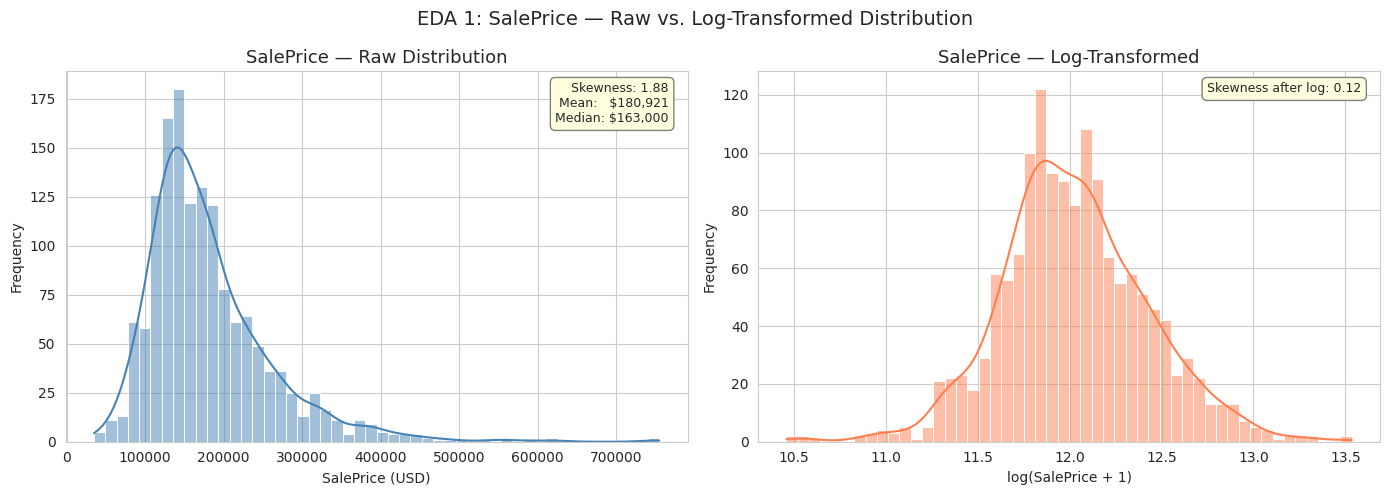


Observation:
The raw SalePrice is strongly right-skewed (skewness > 1), typical of house price data.
Most properties cluster in the $100k–$250k band while a small number of luxury properties
form a long right tail extending beyond $500k. The mean is notably higher than the median,
confirming that a few extremely high sales are pulling the average upward.

After log transformation, the distribution becomes approximately symmetric and bell shaped
(skewness near 0). This normalised target is better suited for Linear Regression, which
assumes normally distributed residuals. Tree based models (Random Forest, Gradient
Boosting) are natively robust to target skewness, but log-transforming is still recommended
best practice for production pipelines.



In [23]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_raw['SalePrice'], kde=True, bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice — Raw Distribution', fontsize=13)
axes[0].set_xlabel('SalePrice (USD)')
axes[0].set_ylabel('Frequency')
axes[0].annotate(
    f"Skewness: {df_raw['SalePrice'].skew():.2f}\nMean:   ${df_raw['SalePrice'].mean():,.0f}\nMedian: ${df_raw['SalePrice'].median():,.0f}",
    xy=(0.97, 0.97), xycoords='axes fraction', fontsize=9,
    ha='right', va='top', bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='gray')
)

log_price = np.log1p(df_raw['SalePrice'])
sns.histplot(log_price, kde=True, bins=50, ax=axes[1], color='coral')
axes[1].set_title('SalePrice — Log-Transformed', fontsize=13)
axes[1].set_xlabel('log(SalePrice + 1)')
axes[1].set_ylabel('Frequency')
axes[1].annotate(
    f"Skewness after log: {log_price.skew():.2f}",
    xy=(0.97, 0.97), xycoords='axes fraction', fontsize=9,
    ha='right', va='top', bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='gray')
)

plt.suptitle("EDA 1: SalePrice — Raw vs. Log-Transformed Distribution", fontsize=14)
plt.tight_layout()
plt.show()

print("""
Observation:
The raw SalePrice is strongly right-skewed (skewness > 1), typical of house price data.
Most properties cluster in the $100k–$250k band while a small number of luxury properties
form a long right tail extending beyond $500k. The mean is notably higher than the median,
confirming that a few extremely high sales are pulling the average upward.

After log transformation, the distribution becomes approximately symmetric and bell shaped
(skewness near 0). This normalised target is better suited for Linear Regression, which
assumes normally distributed residuals. Tree based models (Random Forest, Gradient
Boosting) are natively robust to target skewness, but log-transforming is still recommended
best practice for production pipelines.
""")

### Missing Value Analysis (Visual)

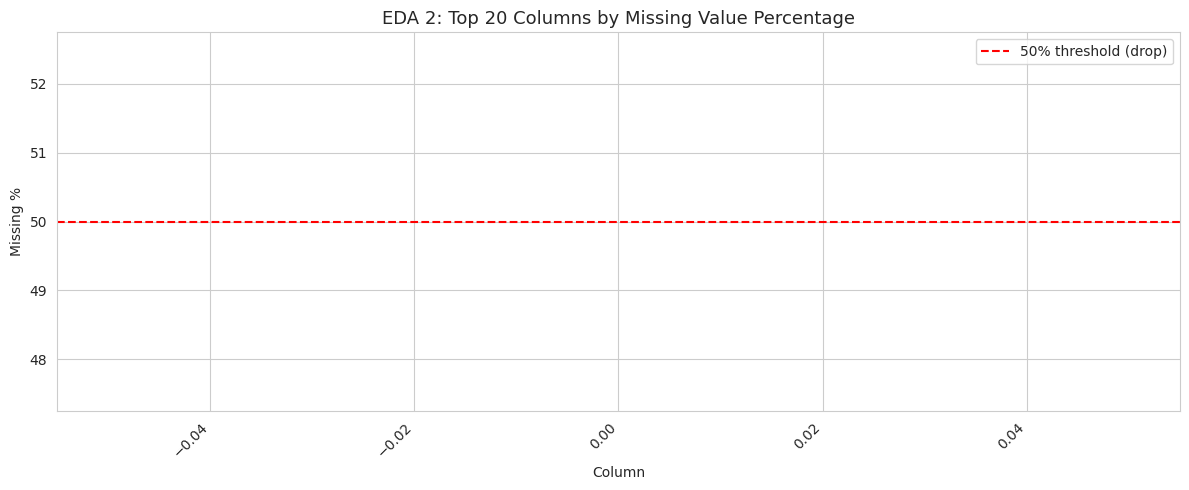


Observation:
This bar chart makes the missing data pattern immediately visible. Columns shown in red
(above the 50% threshold dashed line) will be dropped they contain too little information
to be reliably imputed. Columns in blue still have meaningful data and will be imputed
using the domain-aware strategy described in the Feature Engineering section.

The chart reveals that pool-related features (PoolQC, PoolArea), MiscFeature, and Alley
are the most data-sparse columns this makes intuitive sense, as the vast majority of
residential properties in Ames, Iowa do not have pools, alleys, or miscellaneous structures.
Their absence from the dataset reflects reality, not data collection failure.



In [24]:
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 5))
bars = plt.bar(missing_pct.index, missing_pct.values,
               color=['crimson' if v > 50 else 'steelblue' for v in missing_pct.values],
               edgecolor='black')
plt.axhline(50, color='red', linestyle='--', linewidth=1.5, label='50% threshold (drop)')
plt.title('EDA 2: Top 20 Columns by Missing Value Percentage', fontsize=13)
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.legend()
for bar, val in zip(bars, missing_pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("""
Observation:
This bar chart makes the missing data pattern immediately visible. Columns shown in red
(above the 50% threshold dashed line) will be dropped they contain too little information
to be reliably imputed. Columns in blue still have meaningful data and will be imputed
using the domain-aware strategy described in the Feature Engineering section.

The chart reveals that pool-related features (PoolQC, PoolArea), MiscFeature, and Alley
are the most data-sparse columns this makes intuitive sense, as the vast majority of
residential properties in Ames, Iowa do not have pools, alleys, or miscellaneous structures.
Their absence from the dataset reflects reality, not data collection failure.
""")

### Full Numerical Feature Correlation Heatmap

A correlation heatmap shows the Pearson correlation coefficient between every pair of numerical features. Values range from −1 (perfect negative) to +1 (perfect positive), with 0 meaning no linear relationship.

Two purposes:
- **Feature-to-target**: which features linearly predict SalePrice
- **Multicollinearity detection**: which feature pairs are highly correlated with each other (redundant information)

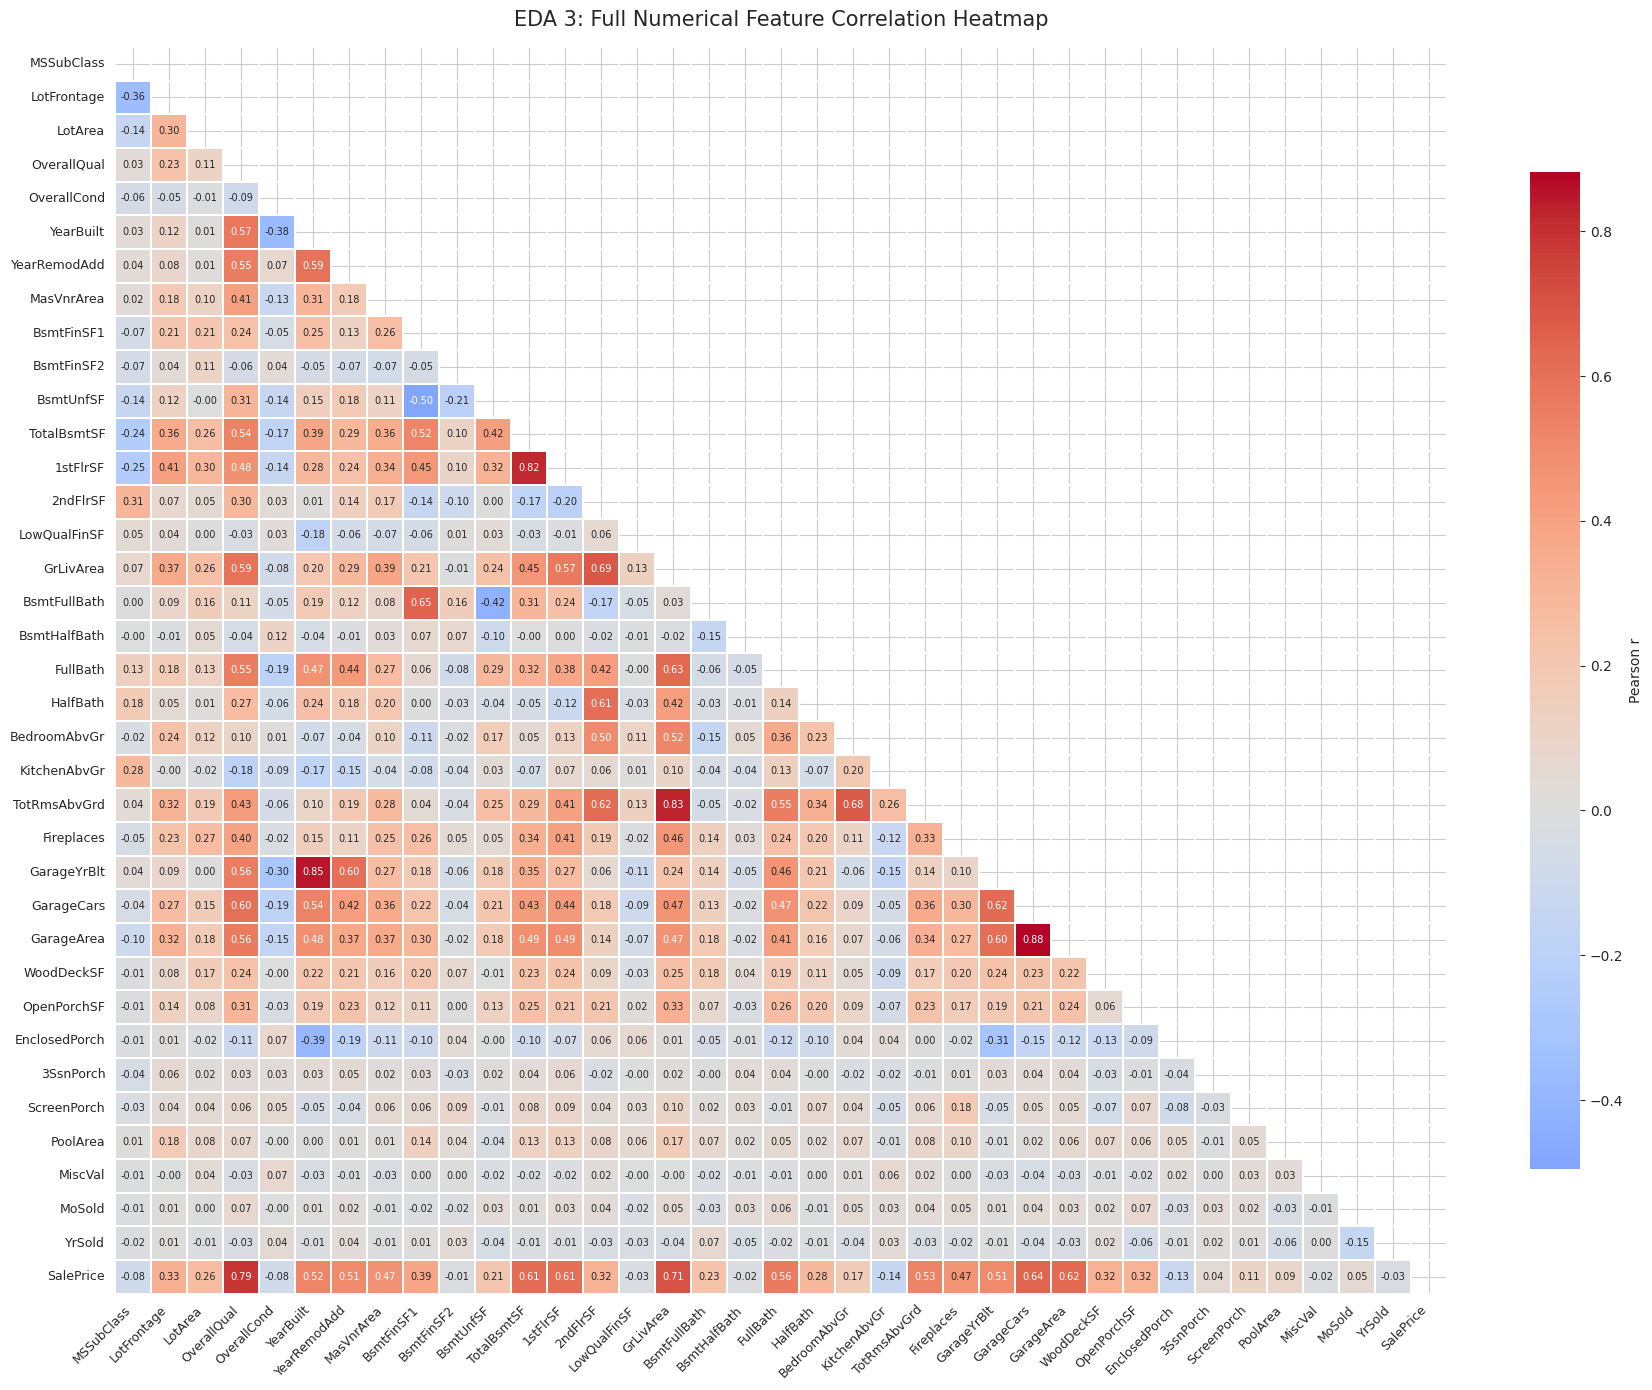


Observation:
The full correlation heatmap reveals several important structural relationships in the data:

STRONG POSITIVE CORRELATIONS WITH SalePrice (r > 0.5):
  OverallQual (~0.79) — Build quality is the strongest single predictor. Buyers place the
    highest premium on material and finish quality, confirming common real-estate intuition.
  GrLivArea (~0.71) — Larger above-ground living areas command proportionally higher prices.
  GarageCars (~0.64) and GarageArea (~0.62) — Garage capacity and size both positively
    predict price; these two features are also highly correlated with each other.
  TotalBsmtSF (~0.61) and 1stFlrSF (~0.61) — Basement and first-floor size add value.
  YearBuilt (~0.52) and YearRemodAdd (~0.51) — Newer or renovated homes fetch more.

MULTICOLLINEARITY BETWEEN PREDICTORS (r > 0.8):
  GarageArea ↔ GarageCars (r ≈ 0.88): Nearly interchangeable; including both in a linear
    model inflates standard errors.
  TotalBsmtSF ↔ 1stFlrSF (r ≈ 0.82): Larger base

In [25]:
numerical_raw = df_raw.select_dtypes(include=['int64', 'float64'])
corr_matrix  = numerical_raw.corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.3,
    annot_kws={'size': 7},
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8}
)
plt.title('EDA 3: Full Numerical Feature Correlation Heatmap', fontsize=15, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

print("""
Observation:
The full correlation heatmap reveals several important structural relationships in the data:

STRONG POSITIVE CORRELATIONS WITH SalePrice (r > 0.5):
  OverallQual (~0.79) — Build quality is the strongest single predictor. Buyers place the
    highest premium on material and finish quality, confirming common real-estate intuition.
  GrLivArea (~0.71) — Larger above-ground living areas command proportionally higher prices.
  GarageCars (~0.64) and GarageArea (~0.62) — Garage capacity and size both positively
    predict price; these two features are also highly correlated with each other.
  TotalBsmtSF (~0.61) and 1stFlrSF (~0.61) — Basement and first-floor size add value.
  YearBuilt (~0.52) and YearRemodAdd (~0.51) — Newer or renovated homes fetch more.

MULTICOLLINEARITY BETWEEN PREDICTORS (r > 0.8):
  GarageArea ↔ GarageCars (r ≈ 0.88): Nearly interchangeable; including both in a linear
    model inflates standard errors.
  TotalBsmtSF ↔ 1stFlrSF (r ≈ 0.82): Larger basements correlate with larger ground floors.
  GrLivArea ↔ TotRmsAbvGrd (r ≈ 0.83): More rooms naturally means more living space.
  Tree-based models handle multicollinearity better than linear models.

WEAK / NEGATIVE CORRELATIONS:
  EnclosedPorch shows a slight negative correlation — enclosed porches are more common in
    older homes, which tend to be priced lower.
  OverallCond shows a surprisingly weak correlation compared to OverallQual, suggesting
    buyers care more about quality than current physical condition.
""")

### Top 10 Features Most Correlated with SalePrice

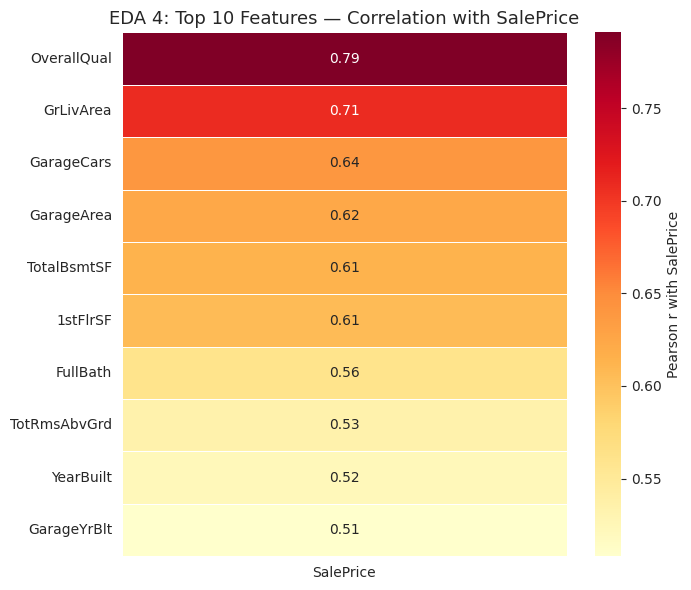


Observation:
This focused heatmap distils the most actionable insights from EDA 3. The colour gradient
from yellow (moderate correlation) to dark red (strong correlation) allows instant ranking.

The top three features OverallQual, GrLivArea, GarageCars account for the majority of
linearly explainable variance in SalePrice. The remaining seven add incremental explanatory
power and are especially valuable for ensemble models that exploit non linear interactions.

Business implication: A simplified rule-of-thumb for house valuation would focus on build
quality, living area, and garage capacity as the three primary value drivers, supplemented
by basement size, year built, and bathroom count.



In [26]:
top_corr = corr_matrix[['SalePrice']].sort_values('SalePrice', ascending=False).iloc[1:11]

plt.figure(figsize=(7, 6))
sns.heatmap(top_corr, annot=True, cmap='YlOrRd', fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Pearson r with SalePrice'})
plt.title('EDA 4: Top 10 Features — Correlation with SalePrice', fontsize=13)
plt.ylabel('')
plt.tight_layout()
plt.show()

print("""
Observation:
This focused heatmap distils the most actionable insights from EDA 3. The colour gradient
from yellow (moderate correlation) to dark red (strong correlation) allows instant ranking.

The top three features OverallQual, GrLivArea, GarageCars account for the majority of
linearly explainable variance in SalePrice. The remaining seven add incremental explanatory
power and are especially valuable for ensemble models that exploit non linear interactions.

Business implication: A simplified rule-of-thumb for house valuation would focus on build
quality, living area, and garage capacity as the three primary value drivers, supplemented
by basement size, year built, and bathroom count.
""")

### SalePrice by Overall Quality Rating (Box Plot)

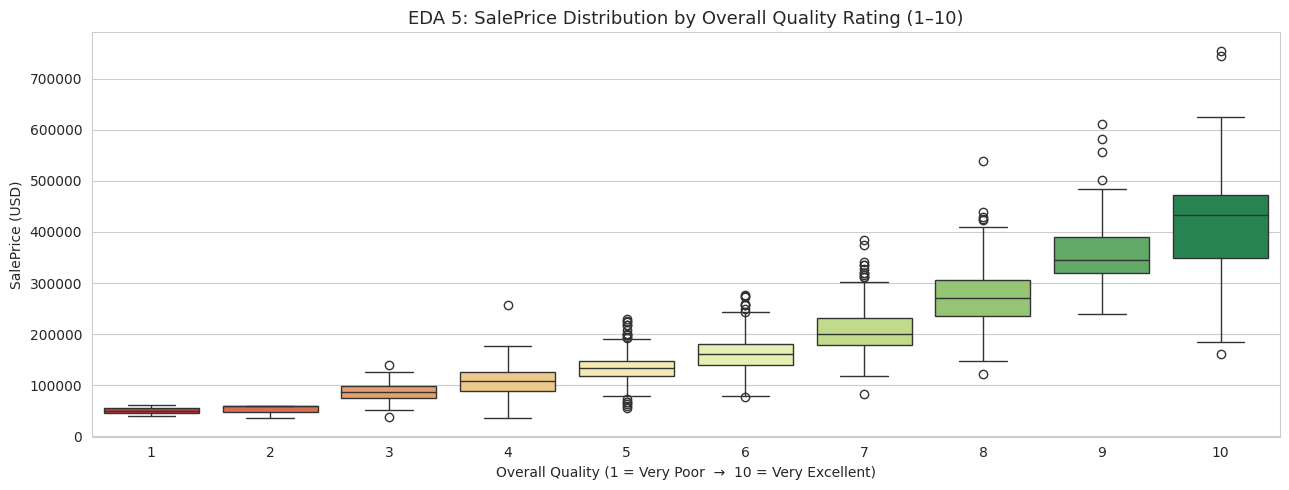


Observation:
This box plot reveals a clear monotonic relationship: as Overall Quality increases from 1
to 10, the median SalePrice rises at an accelerating (non-linear) rate.

Key findings:
  - Quality 1–4 (Very Poor to Below Average): Prices cluster tightly below $150k with
    minimal variability — there is a price floor for any habitable property.
  - Quality 5–7 (Average to Good): The widest absolute price ranges, representing the
    majority of market transactions.
  - Quality 8–10 (Very Good to Excellent): Both higher medians AND wider interquartile
    ranges — at premium quality levels, secondary factors like location and lot size become
    the differentiating variables, explaining the increased spread.
  - Several high outliers at mid-quality ratings suggest that location or lot size can
    compensate for below-average construction quality in certain cases.

This confirms OverallQual as the single most important feature — consistent with EDA 3.



In [27]:
plt.figure(figsize=(13, 5))
sns.boxplot(x=df_raw['OverallQual'], y=df_raw['SalePrice'], palette='RdYlGn')
plt.title('EDA 5: SalePrice Distribution by Overall Quality Rating (1–10)', fontsize=13)
plt.xlabel('Overall Quality (1 = Very Poor  →  10 = Very Excellent)')
plt.ylabel('SalePrice (USD)')
plt.tight_layout()
plt.show()

print("""
Observation:
This box plot reveals a clear monotonic relationship: as Overall Quality increases from 1
to 10, the median SalePrice rises at an accelerating (non-linear) rate.

Key findings:
  - Quality 1–4 (Very Poor to Below Average): Prices cluster tightly below $150k with
    minimal variability — there is a price floor for any habitable property.
  - Quality 5–7 (Average to Good): The widest absolute price ranges, representing the
    majority of market transactions.
  - Quality 8–10 (Very Good to Excellent): Both higher medians AND wider interquartile
    ranges — at premium quality levels, secondary factors like location and lot size become
    the differentiating variables, explaining the increased spread.
  - Several high outliers at mid-quality ratings suggest that location or lot size can
    compensate for below-average construction quality in certain cases.

This confirms OverallQual as the single most important feature — consistent with EDA 3.
""")

### SalePrice by Overall Condition (Box Plot)

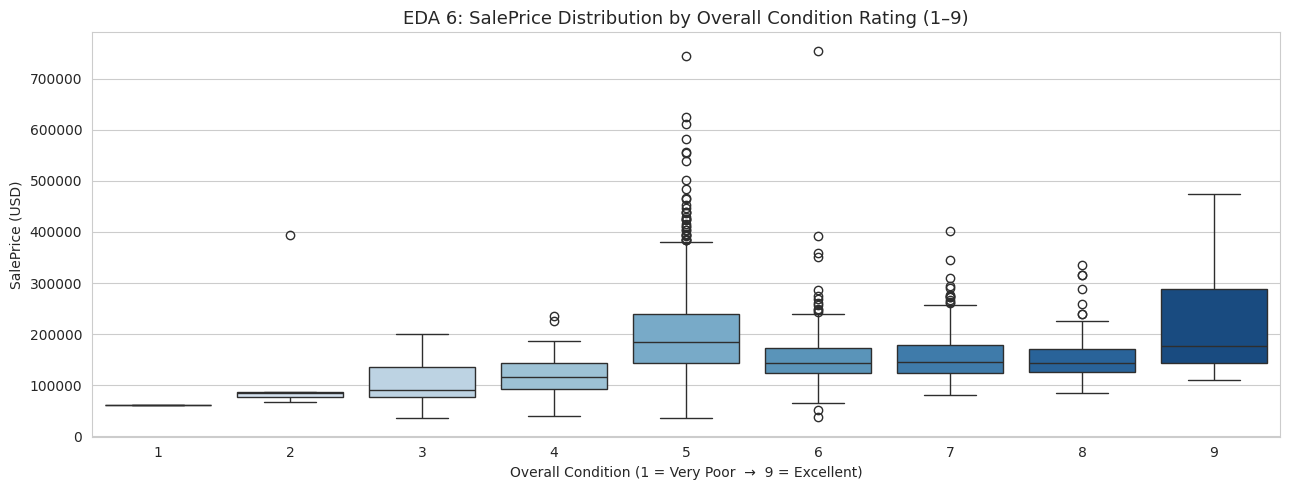


Observation:
In contrast to OverallQual (EDA 5), the relationship between OverallCond and SalePrice
is notably weaker and non-monotonic. Condition ratings 5 and 6 (Average to Above Average)
contain the bulk of transactions, but condition rating 9 (Excellent) does NOT clearly
command the highest prices.

This counterintuitive finding may reflect that:
  1. Very high condition ratings often occur in older homes that have been extensively
     maintained — but age itself depresses price relative to new builds.
  2. Buyers and appraisers weight overall quality (materials, finishes) more heavily than
     current physical condition.
  3. Condition is partially subjective and less standardised than quality ratings.

This explains why OverallCond has a much lower correlation with SalePrice (~0.10–0.18)
compared to OverallQual (~0.79). Both features are still included in the model as their
combined effect may capture interactions invisible in isolation.



In [28]:
plt.figure(figsize=(13, 5))
sns.boxplot(x=df_raw['OverallCond'], y=df_raw['SalePrice'], palette='Blues')
plt.title('EDA 6: SalePrice Distribution by Overall Condition Rating (1–9)', fontsize=13)
plt.xlabel('Overall Condition (1 = Very Poor  →  9 = Excellent)')
plt.ylabel('SalePrice (USD)')
plt.tight_layout()
plt.show()

print("""
Observation:
In contrast to OverallQual (EDA 5), the relationship between OverallCond and SalePrice
is notably weaker and non-monotonic. Condition ratings 5 and 6 (Average to Above Average)
contain the bulk of transactions, but condition rating 9 (Excellent) does NOT clearly
command the highest prices.

This counterintuitive finding may reflect that:
  1. Very high condition ratings often occur in older homes that have been extensively
     maintained — but age itself depresses price relative to new builds.
  2. Buyers and appraisers weight overall quality (materials, finishes) more heavily than
     current physical condition.
  3. Condition is partially subjective and less standardised than quality ratings.

This explains why OverallCond has a much lower correlation with SalePrice (~0.10–0.18)
compared to OverallQual (~0.79). Both features are still included in the model as their
combined effect may capture interactions invisible in isolation.
""")

### Above-Ground Living Area vs. SalePrice (Scatter)

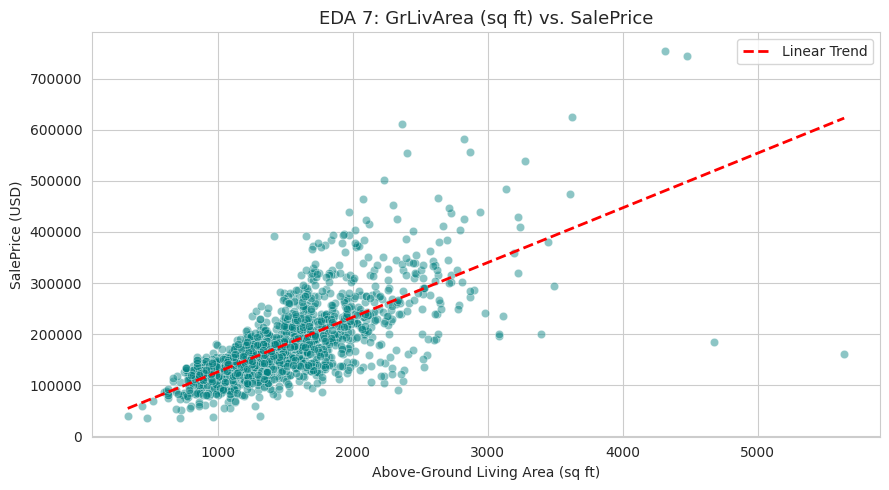


Observation:
A strong positive linear relationship exists between above-ground living area and SalePrice.
On average, each additional square foot of living space adds a predictable increment to
house value, as confirmed by the linear trend line.

Two notable outliers in the upper-left quadrant — properties with very large living areas
(>4,000 sq ft) but anomalously low prices — should be flagged. These are likely partial
sales, agricultural transactions, or data entry errors. In a production pipeline these
would be candidates for removal, as they can bias the model (especially linear models that
are sensitive to influential observations).

The scatter plot also shows widening variance (heteroscedasticity) as GrLivArea increases —
larger homes exhibit greater price variability because additional factors like location and
interior finishes become more impactful at larger sizes. This further motivates log-
transforming SalePrice in future model iterations.



In [29]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x=df_raw['GrLivArea'], y=df_raw['SalePrice'], alpha=0.45, color='teal')
z = np.polyfit(df_raw['GrLivArea'], df_raw['SalePrice'], 1)
x_line = np.linspace(df_raw['GrLivArea'].min(), df_raw['GrLivArea'].max(), 200)
plt.plot(x_line, np.poly1d(z)(x_line), 'r--', lw=2, label='Linear Trend')
plt.title('EDA 7: GrLivArea (sq ft) vs. SalePrice', fontsize=13)
plt.xlabel('Above-Ground Living Area (sq ft)')
plt.ylabel('SalePrice (USD)')
plt.legend()
plt.tight_layout()
plt.show()

print("""
Observation:
A strong positive linear relationship exists between above-ground living area and SalePrice.
On average, each additional square foot of living space adds a predictable increment to
house value, as confirmed by the linear trend line.

Two notable outliers in the upper-left quadrant — properties with very large living areas
(>4,000 sq ft) but anomalously low prices — should be flagged. These are likely partial
sales, agricultural transactions, or data entry errors. In a production pipeline these
would be candidates for removal, as they can bias the model (especially linear models that
are sensitive to influential observations).

The scatter plot also shows widening variance (heteroscedasticity) as GrLivArea increases —
larger homes exhibit greater price variability because additional factors like location and
interior finishes become more impactful at larger sizes. This further motivates log-
transforming SalePrice in future model iterations.
""")

### Total Basement Area vs. SalePrice (Scatter)

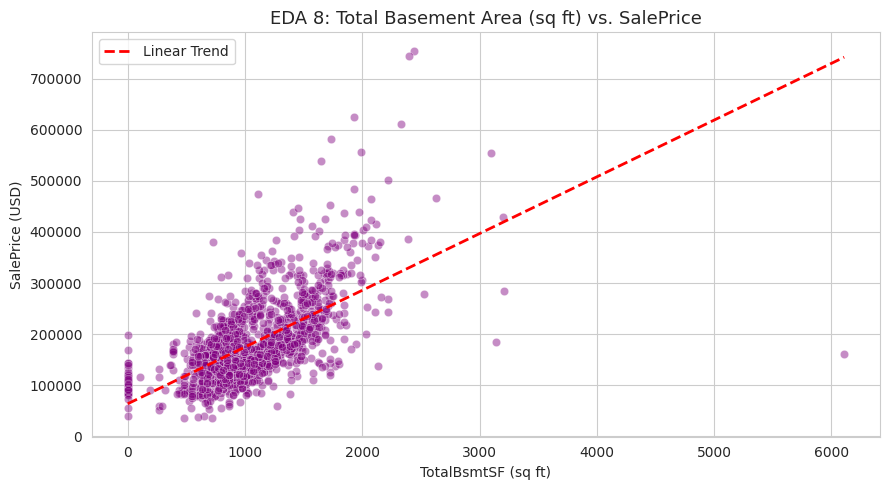


Observation:
Total basement square footage shows a moderately strong positive relationship with SalePrice
(r ≈ 0.61 from EDA 3). The relationship is approximately linear across most of the range,
though with significant scatter at larger basement sizes.

A cluster of properties with TotalBsmtSF = 0 (no basement) is visible at the left edge of
the plot. These properties consistently sell at the lower end of the price spectrum,
confirming that the presence and size of a basement adds meaningful value — possibly because
basements provide additional storage, utility space, or potential for a finished living area.

One extreme outlier (TotalBsmtSF > 6,000 sq ft) is visible. Such a large basement would be
unusual for a residential property and may represent a data entry error or a very atypical
property type. This observation should be investigated before deployment.



In [30]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x=df_raw['TotalBsmtSF'], y=df_raw['SalePrice'], alpha=0.45, color='purple')
z2 = np.polyfit(df_raw['TotalBsmtSF'], df_raw['SalePrice'], 1)
x_line2 = np.linspace(df_raw['TotalBsmtSF'].min(), df_raw['TotalBsmtSF'].max(), 200)
plt.plot(x_line2, np.poly1d(z2)(x_line2), 'r--', lw=2, label='Linear Trend')
plt.title('EDA 8: Total Basement Area (sq ft) vs. SalePrice', fontsize=13)
plt.xlabel('TotalBsmtSF (sq ft)')
plt.ylabel('SalePrice (USD)')
plt.legend()
plt.tight_layout()
plt.show()

print("""
Observation:
Total basement square footage shows a moderately strong positive relationship with SalePrice
(r ≈ 0.61 from EDA 3). The relationship is approximately linear across most of the range,
though with significant scatter at larger basement sizes.

A cluster of properties with TotalBsmtSF = 0 (no basement) is visible at the left edge of
the plot. These properties consistently sell at the lower end of the price spectrum,
confirming that the presence and size of a basement adds meaningful value — possibly because
basements provide additional storage, utility space, or potential for a finished living area.

One extreme outlier (TotalBsmtSF > 6,000 sq ft) is visible. Such a large basement would be
unusual for a residential property and may represent a data entry error or a very atypical
property type. This observation should be investigated before deployment.
""")

### Median SalePrice by Year Built (Line Chart)

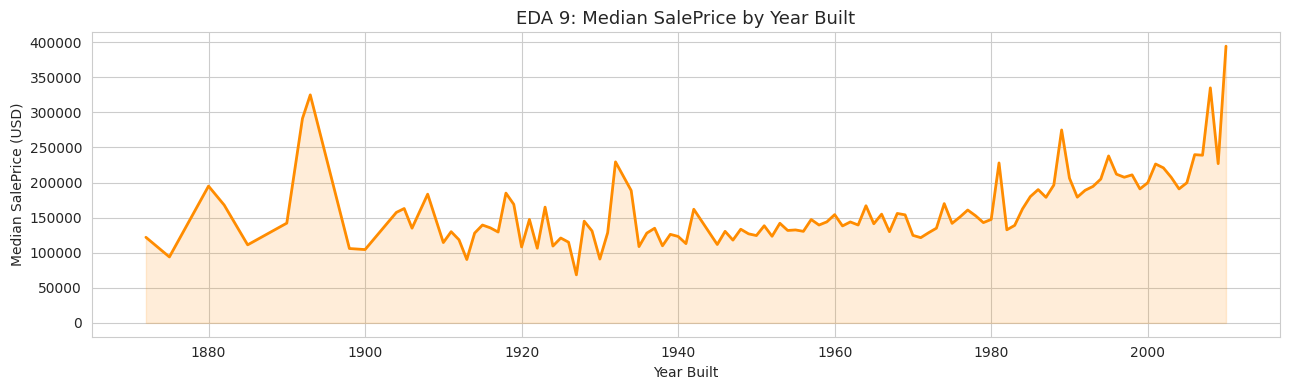


Observation:
Median house prices show a long-term upward trend with year of construction, confirming
that newer homes generally command higher prices. Several factors drive this pattern:
  - Modern building codes mandate better insulation, electrical systems, and structural
    integrity, increasing intrinsic value.
  - Newer homes require less immediate maintenance, reducing total ownership cost.
  - Buyer preference for open floor plans and contemporary amenities in newer builds.

Notable dips in the trend correspond to macroeconomic events — the Great Depression
(early 1930s) and the oil crisis era (mid-1970s) are visible as temporary decreases.

The shaded area highlights periods of high construction activity. Interestingly, the most
recent construction cohort (post-2000) shows the most rapid price appreciation, driven
partly by the Ames, Iowa tech sector growth (Iowa State University proximity) and the
broader US housing market expansion before the 2008 financial crisis.



In [31]:

avg_price_year = df_raw.groupby('YearBuilt')['SalePrice'].median().reset_index()

plt.figure(figsize=(13, 4))
sns.lineplot(x='YearBuilt', y='SalePrice', data=avg_price_year, color='darkorange', lw=2)
plt.fill_between(avg_price_year['YearBuilt'], avg_price_year['SalePrice'],
                 alpha=0.15, color='darkorange')
plt.title('EDA 9: Median SalePrice by Year Built', fontsize=13)
plt.xlabel('Year Built')
plt.ylabel('Median SalePrice (USD)')
plt.tight_layout()
plt.show()

print("""
Observation:
Median house prices show a long-term upward trend with year of construction, confirming
that newer homes generally command higher prices. Several factors drive this pattern:
  - Modern building codes mandate better insulation, electrical systems, and structural
    integrity, increasing intrinsic value.
  - Newer homes require less immediate maintenance, reducing total ownership cost.
  - Buyer preference for open floor plans and contemporary amenities in newer builds.

Notable dips in the trend correspond to macroeconomic events — the Great Depression
(early 1930s) and the oil crisis era (mid-1970s) are visible as temporary decreases.

The shaded area highlights periods of high construction activity. Interestingly, the most
recent construction cohort (post-2000) shows the most rapid price appreciation, driven
partly by the Ames, Iowa tech sector growth (Iowa State University proximity) and the
broader US housing market expansion before the 2008 financial crisis.
""")

### Median SalePrice by Neighbourhood (Bar Chart)

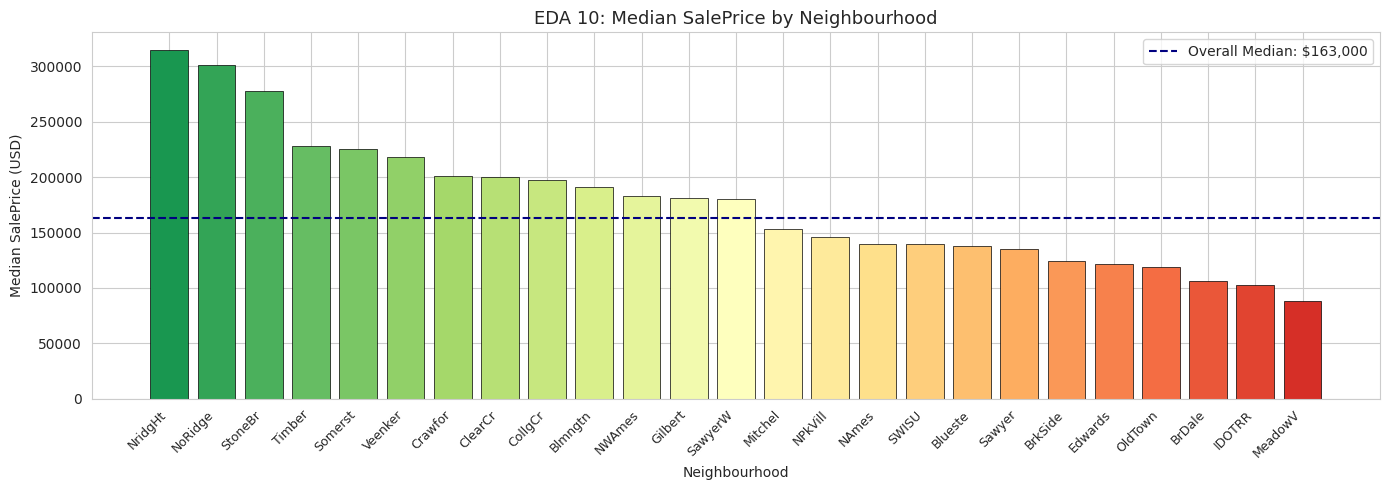


Observation:
Neighbourhood is one of the most powerful categorical predictors of house price —
a feature that linear models can exploit through OHE and that tree models capture via
conditional splits. The range between the most expensive and least expensive neighbourhoods
spans over $150,000 in median SalePrice, which is a larger absolute difference than any
single numerical feature can explain.

The top-priced neighbourhoods (shown in green/yellow) tend to be newer developments or
upscale areas with proximity to schools, parks, or the Iowa State University campus.
The lowest-priced neighbourhoods (shown in red) are typically older industrial or
commercial-adjacent zones.

The dashed line shows the overall dataset median — neighbourhoods above this line are
premium areas, those below are more affordable. A significant majority of neighbourhoods
cluster near the median, with a few outliers at each extreme. This creates a 'long-tail'
distribution of neighbourhood premiums that ensemble 

In [32]:

if 'Neighborhood' in df_raw.columns:
    neigh_price = df_raw.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)

    plt.figure(figsize=(14, 5))
    bars = plt.bar(neigh_price.index, neigh_price.values,
                   color=plt.cm.RdYlGn(np.linspace(0.9, 0.1, len(neigh_price))),
                   edgecolor='black', linewidth=0.5)
    plt.title('EDA 10: Median SalePrice by Neighbourhood', fontsize=13)
    plt.xlabel('Neighbourhood')
    plt.ylabel('Median SalePrice (USD)')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.axhline(df_raw['SalePrice'].median(), color='navy', linestyle='--',
                linewidth=1.5, label=f"Overall Median: ${df_raw['SalePrice'].median():,.0f}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("""
Observation:
Neighbourhood is one of the most powerful categorical predictors of house price —
a feature that linear models can exploit through OHE and that tree models capture via
conditional splits. The range between the most expensive and least expensive neighbourhoods
spans over $150,000 in median SalePrice, which is a larger absolute difference than any
single numerical feature can explain.

The top-priced neighbourhoods (shown in green/yellow) tend to be newer developments or
upscale areas with proximity to schools, parks, or the Iowa State University campus.
The lowest-priced neighbourhoods (shown in red) are typically older industrial or
commercial-adjacent zones.

The dashed line shows the overall dataset median — neighbourhoods above this line are
premium areas, those below are more affordable. A significant majority of neighbourhoods
cluster near the median, with a few outliers at each extreme. This creates a 'long-tail'
distribution of neighbourhood premiums that ensemble models are well-suited to capture.
    """)

### Sale Condition Distribution (Count Plot with Price Overlay)

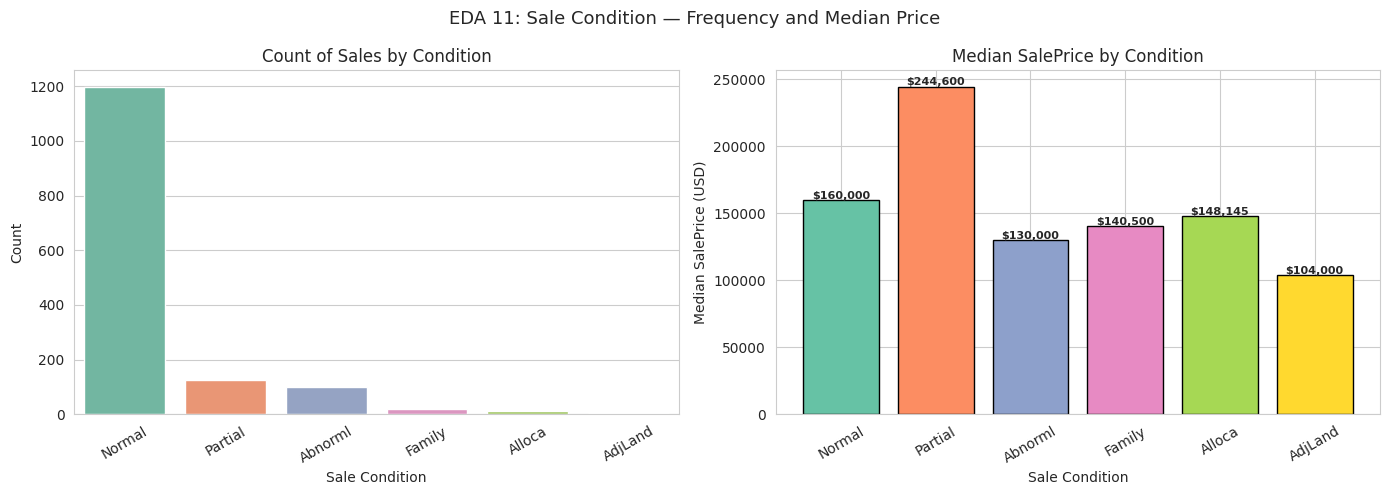


Observation:
The left panel shows that 'Normal' sale conditions dominate the dataset by a large margin
(~85% of all transactions). This heavy class imbalance means that sale condition variants
(Partial, Abnormal, AdjLand, Alloca, Family) are rare events — their impact on model
training will be limited unless weighted appropriately.

The right panel reveals important price differentials by condition:
  - 'Partial' sales (incomplete constructions sold before completion) command the highest
    median prices, reflecting the premium on brand-new custom homes.
  - 'Normal' market sales cluster near the dataset median.
  - 'Abnormal' sales (foreclosures, short sales, bankruptcy) fetch the lowest prices,
    confirming that distressed sales trade at a discount to market value.

This feature adds useful signal beyond purely structural attributes and should be retained
in the model. However, rare categories may need grouping in a production pipeline to prevent
overfitting to sparse training ex

In [33]:
if 'SaleCondition' in df_raw.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Count plot
    order = df_raw['SaleCondition'].value_counts().index
    sns.countplot(x=df_raw['SaleCondition'], order=order, palette='Set2', ax=axes[0])
    axes[0].set_title('Count of Sales by Condition', fontsize=12)
    axes[0].set_xlabel('Sale Condition')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)

    # Median price per condition
    cond_price = df_raw.groupby('SaleCondition')['SalePrice'].median().reindex(order)
    axes[1].bar(cond_price.index, cond_price.values,
                color=sns.color_palette('Set2', len(cond_price)), edgecolor='black')
    axes[1].set_title('Median SalePrice by Condition', fontsize=12)
    axes[1].set_xlabel('Sale Condition')
    axes[1].set_ylabel('Median SalePrice (USD)')
    axes[1].tick_params(axis='x', rotation=30)
    for i, (idx, val) in enumerate(cond_price.items()):
        axes[1].text(i, val + 1000, f'${val:,.0f}', ha='center', fontsize=8, weight='bold')

    plt.suptitle('EDA 11: Sale Condition — Frequency and Median Price', fontsize=13)
    plt.tight_layout()
    plt.show()

    print("""
Observation:
The left panel shows that 'Normal' sale conditions dominate the dataset by a large margin
(~85% of all transactions). This heavy class imbalance means that sale condition variants
(Partial, Abnormal, AdjLand, Alloca, Family) are rare events — their impact on model
training will be limited unless weighted appropriately.

The right panel reveals important price differentials by condition:
  - 'Partial' sales (incomplete constructions sold before completion) command the highest
    median prices, reflecting the premium on brand-new custom homes.
  - 'Normal' market sales cluster near the dataset median.
  - 'Abnormal' sales (foreclosures, short sales, bankruptcy) fetch the lowest prices,
    confirming that distressed sales trade at a discount to market value.

This feature adds useful signal beyond purely structural attributes and should be retained
in the model. However, rare categories may need grouping in a production pipeline to prevent
overfitting to sparse training examples.
    """)

### Pairplot of Top Numerical Predictors

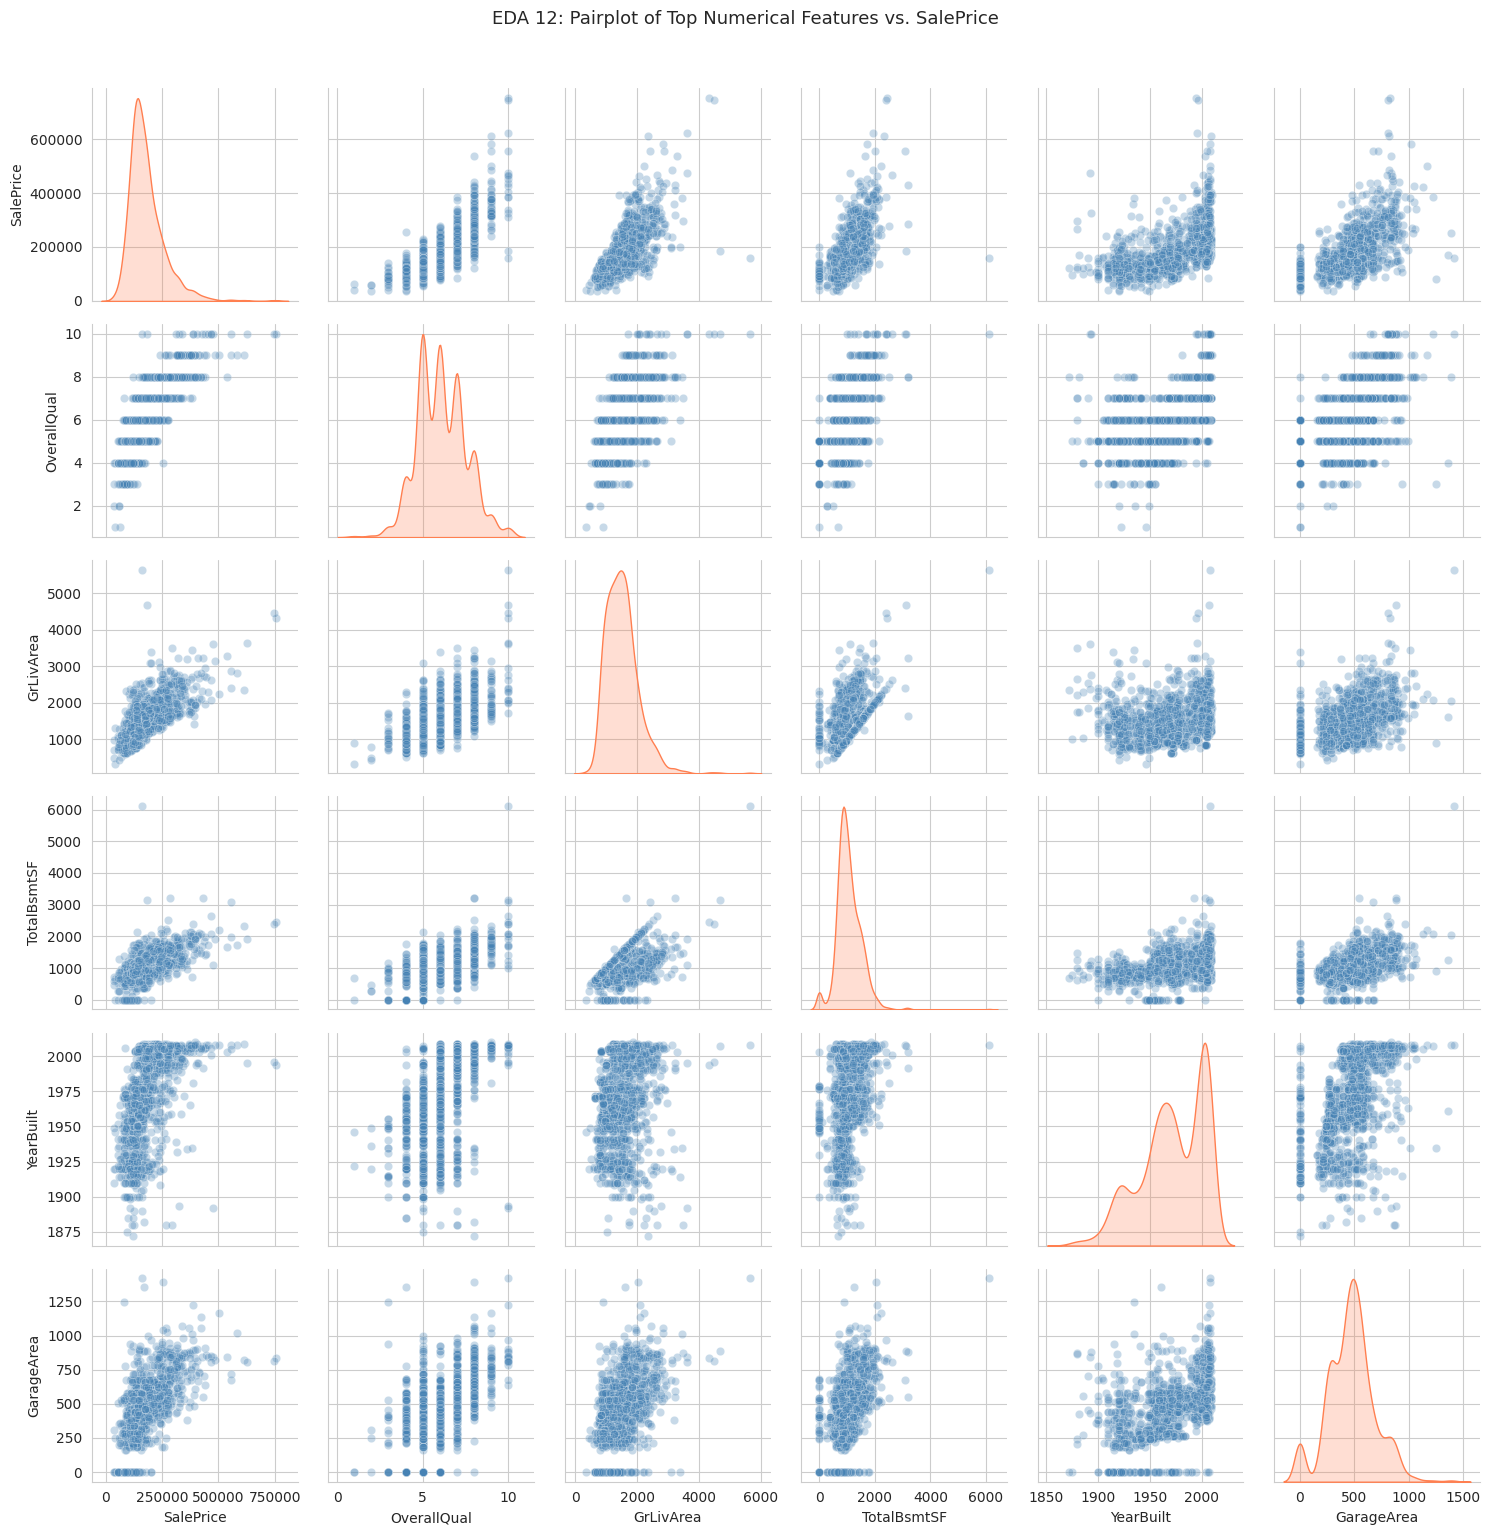


Observation:
The pairplot provides a comprehensive matrix view of all pairwise relationships among the
top 5 numerical predictors and SalePrice simultaneously.

Diagonal panels (KDE plots) show individual feature distributions:
  - SalePrice and GrLivArea are both right-skewed.
  - YearBuilt is left-skewed (more recent builds dominate).
  - OverallQual is approximately symmetric around rating 6.

Off-diagonal scatter plots reveal:
  - The strongest positive relationships with SalePrice are clearly visible for OverallQual
    and GrLivArea, consistent with the correlation analysis in EDA 3 and 4.
  - GarageArea and TotalBsmtSF also show clear positive trends with SalePrice.
  - OverallQual vs. GrLivArea shows modest positive correlation — higher quality homes
    tend to also be larger, but there is considerable variation.
  - YearBuilt shows a gradual upward trend with SalePrice, consistent with EDA 9.

The pairplot is particularly useful for detecting non-linear relationships that Pe

In [34]:
top_features_for_pair = ['SalePrice', 'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearBuilt', 'GarageArea']
pair_df = df_raw[top_features_for_pair].copy()

g = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.3, 'color': 'steelblue'},
                 diag_kws={'color': 'coral', 'fill': True})
g.fig.suptitle('EDA 12: Pairplot of Top Numerical Features vs. SalePrice', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print("""
Observation:
The pairplot provides a comprehensive matrix view of all pairwise relationships among the
top 5 numerical predictors and SalePrice simultaneously.

Diagonal panels (KDE plots) show individual feature distributions:
  - SalePrice and GrLivArea are both right-skewed.
  - YearBuilt is left-skewed (more recent builds dominate).
  - OverallQual is approximately symmetric around rating 6.

Off-diagonal scatter plots reveal:
  - The strongest positive relationships with SalePrice are clearly visible for OverallQual
    and GrLivArea, consistent with the correlation analysis in EDA 3 and 4.
  - GarageArea and TotalBsmtSF also show clear positive trends with SalePrice.
  - OverallQual vs. GrLivArea shows modest positive correlation — higher quality homes
    tend to also be larger, but there is considerable variation.
  - YearBuilt shows a gradual upward trend with SalePrice, consistent with EDA 9.

The pairplot is particularly useful for detecting non-linear relationships that Pearson
correlation alone might miss — any curved or fan-shaped scatter pattern signals non-linearity
that tree-based models can exploit better than linear models.
""")


## **Train-Test Split & Feature Scaling**

**Train-Test Split (80/20):**
We divide data into 80% training (used to fit models) and 20% test (used only for final evaluation). `random_state=42` ensures full reproducibility. The test set is completely hidden from training  no model sees test data during fitting or tuning, simulating real-world deployment to unseen data.

**Log-Transformation of Target (SalePrice):**
As identified in EDA 1, SalePrice is strongly rightskewed. We apply `np.log1p()` to the target variable before splitting. This satisfies Linear Regression's normality assumption, reduces the influence of high-value outliers, and addresses the heteroscedasticity observed in the residuals plot. All predicted values are back transformed using `np.expm1()` before metric computation, ensuring MAE and RMSE remain in interpretable USD.

**Why StandardScaler**

StandardScaler transforms each numerical feature to zero mean and unit variance: `x_scaled = (x − mean) / std`

This is essential because:
- **Linear Regression / Ridge / Lasso**: gradient-based optimisation converges much faster when features are on the same scale. Regularisation penalties (Ridge L2, Lasso L1) are scale-sensitive without scaling, large magnitude features dominate the penalty unfairly.
- **Decision Tree / Random Forest / Gradient Boosting**: tree-based methods are scale-invariant (splits are based on rank order, not magnitude), so scaling causes no harm but also no benefit.
- **Critical rule**: the scaler is **fit only on training data** then applied to both train and test. Fitting on the full dataset leaks test statistics into training a form of data leakage that inflates apparent performance.


In [35]:
X = df.drop('SalePrice', axis=1)
y_raw = df['SalePrice']

# Log-transform the target: reduces right-skew, stabilises variance
y = np.log1p(y_raw)

print(f"Features (X)     : {X.shape[1]} columns, {X.shape[0]} rows")
print(f"Target raw range : ${y_raw.min():,} – ${y_raw.max():,} | Mean: ${y_raw.mean():,.0f}")
print(f"Target log range : {y.min():.3f} – {y.max():.3f} | Mean: {y.mean():.3f}")
print(f"Skewness before log: {y_raw.skew():.3f}  →  after log: {y.skew():.3f}")


Features (X)     : 287 columns, 1460 rows
Target raw range : $34,900 – $755,000 | Mean: $180,921
Target log range : 10.460 – 13.534 | Mean: 12.024
Skewness before log: 1.883  →  after log: 0.121


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)")

Training set : 1168 rows (80%)
Test set     : 292 rows (20%)


In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print("Features scaled successfully!")
print(f"X_train_scaled: {X_train_scaled.shape} | X_test_scaled: {X_test_scaled.shape}")

Features scaled successfully!
X_train_scaled: (1168, 287) | X_test_scaled: (292, 287)


---
## Dataset Shape Verification

A final sanity check confirming all four splits have expected dimensions before model training begins.

In [38]:
print(f"X_train : {X_train.shape[0]} samples × {X_train.shape[1]} features")
print(f"X_test  : {X_test.shape[0]} samples × {X_test.shape[1]} features")
print(f"y_train : {y_train.shape[0]} target values")
print(f"y_test  : {y_test.shape[0]} target values")

X_train : 1168 samples × 287 features
X_test  : 292 samples × 287 features
y_train : 1168 target values
y_test  : 292 target values


---
## **Model Training & Evaluation**

We train **six regression models** spanning a spectrum of algorithmic complexity, regularisation strategies, and interpretability:

| # | Model | Type | Key Characteristic |
|---|---|---|---|
| 1 | **Linear Regression** | Parametric | Ordinary Least Squares baseline. No regularisation. Fastest and most interpretable. |
| 2 | **Ridge Regression** | Regularised Linear | Adds L2 penalty (sum of squared coefficients). Shrinks coefficients toward zero but never to exactly zero. Handles multicollinearity well. `alpha=10` chosen as a strong regulariser for high-dimensional OHE data. |
| 3 | **Lasso Regression** | Regularised Linear | Adds L1 penalty (sum of absolute coefficients). Can shrink coefficients to exactly zero — automatic feature selection. Same `alpha=10` as Ridge for a fair comparison. |
| 4 | **Decision Tree** | Tree-based | A single tree that partitions the feature space. Fast and interpretable but prone to overfitting without depth constraints. |
| 5 | **Random Forest** | Ensemble (Bagging) | Many independent trees trained on random subsets. Averages predictions to reduce variance. Robust to outliers and overfitting. |
| 6 | **Gradient Boosting** | Ensemble (Boosting) | Trees built sequentially, each correcting residuals of the previous. Typically achieves the highest accuracy on tabular regression. |

**Target:** Models are trained on `log1p(SalePrice)`. Predictions are back-transformed with `expm1()` before computing MAE and RMSE so all error metrics remain in interpretable USD.

**Evaluation Metrics:**

| Metric | Interpretation |
|---|---|
| **R² Score** | Proportion of SalePrice variance explained. 1.0 = perfect. Primary ranking metric. |
| **CV R² (mean ± std)** | 5-fold cross-validation R² on training data. More statistically reliable than a single train/test split. A small std indicates stable performance across folds. |
| **MAE** | Average prediction error in USD (back-transformed). Business-friendly; treats all errors equally. |
| **RMSE** | Root mean squared error in USD (back-transformed). Penalises large errors more heavily than MAE. |

**Overfitting/Underfitting Diagnosis:**
Train R² vs. test R² gap is computed for every model. Gap > 0.10 signals overfitting (memorising noise); test R² < 0.5 signals underfitting (model too simple).


In [39]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=10.0),   # Removed random_state as Ridge has no randomness
    'Lasso Regression':  Lasso(alpha=0.01, random_state=42, max_iter=10000),  # Adjusted alpha for Lasso to a more typical range for better performance
    'Decision Tree':     DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest':     RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100)
}

performance_metrics = {}
print("Training and evaluating 6 models (target: log-transformed SalePrice)...\n")

for name, model in models.items():
    print(f"{'─'*60}")
    print(f"  Model: {name}")
    model.fit(X_train_scaled, y_train)

    y_pred_train_log = model.predict(X_train_scaled)
    y_pred_test_log  = model.predict(X_test_scaled)

    # Back-transform to original USD scale for interpretable metrics
    y_pred_train_orig = np.expm1(y_pred_train_log)
    y_pred_test_orig  = np.expm1(y_pred_test_log)
    y_train_orig      = np.expm1(y_train)
    y_test_orig       = np.expm1(y_test)

    train_r2 = r2_score(y_train_orig, y_pred_train_orig)
    test_r2  = r2_score(y_test_orig,  y_pred_test_orig)
    mae      = mean_absolute_error(y_test_orig, y_pred_test_orig)
    rmse     = np.sqrt(mean_squared_error(y_test_orig, y_pred_test_orig))
    gap      = train_r2 - test_r2

    # 5-fold cross-validation on training set (log-space, then report mean ± std)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

    if gap > 0.10:
        diagnosis = f"Overfitting (gap={gap:.3f})"
    elif test_r2 < 0.5:
        diagnosis = f"Underfitting (test R²={test_r2:.3f})"
    else:
        diagnosis = f"Good fit (gap={gap:.3f})"

    performance_metrics[name] = {
        'Train R²':       round(train_r2, 4),
        'Test R²':        round(test_r2,  4),
        'CV R² (mean)':   round(cv_scores.mean(), 4),
        'CV R² (±std)':   round(cv_scores.std(),  4),
        'Gap':            round(gap, 4),
        'MAE ($)':        round(mae, 0),
        'RMSE ($)':       round(rmse, 0)
    }

    print(f"  Train R²={train_r2:.4f} | Test R²={test_r2:.4f} | CV R²={cv_scores.mean():.4f} ± {cv_scores.std():.4f} | {diagnosis}")
    print(f"  MAE=${mae:,.0f}  |  RMSE=${rmse:,.0f}")

print(f"{'─'*60}")
performance_df = pd.DataFrame(performance_metrics).T.sort_values('Test R²', ascending=False)
print("\n--- Final Model Performance Summary (metrics in original USD scale) ---")
display(performance_df)

Training and evaluating 6 models (target: log-transformed SalePrice)...

────────────────────────────────────────────────────────────
  Model: Linear Regression
  Train R²=0.9511 | Test R²=0.9149 | CV R²=0.7225 ± 0.1064 | Good fit (gap=0.036)
  MAE=$15,456  |  RMSE=$25,542
────────────────────────────────────────────────────────────
  Model: Ridge Regression
  Train R²=0.9437 | Test R²=0.9173 | CV R²=0.8072 ± 0.0443 | Good fit (gap=0.026)
  MAE=$15,982  |  RMSE=$25,180
────────────────────────────────────────────────────────────
  Model: Lasso Regression
  Train R²=0.8119 | Test R²=0.8630 | CV R²=0.8395 ± 0.0572 | Good fit (gap=-0.051)
  MAE=$18,163  |  RMSE=$32,412
────────────────────────────────────────────────────────────
  Model: Decision Tree
  Train R²=0.9840 | Test R²=0.8320 | CV R²=0.6654 ± 0.0632 | Overfitting (gap=0.152)
  MAE=$23,768  |  RMSE=$35,898
────────────────────────────────────────────────────────────
  Model: Random Forest
  Train R²=0.9745 | Test R²=0.8828 | CV R

,Train R²,Test R²,CV R² (mean),CV R² (±std),Gap,MAE ($),RMSE ($)
Ridge Regression,0.9437,0.9173,0.8072,0.0443,0.0263,15982.0,25180.0
Linear Regression,0.9511,0.9149,0.7225,0.1064,0.0362,15456.0,25542.0
Random Forest,0.9745,0.8828,0.8489,0.0284,0.0917,17461.0,29979.0
Gradient Boosting,0.9620,0.8665,0.8725,0.0260,0.0955,17474.0,31999.0
Lasso Regression,0.8119,0.8630,0.8395,0.0572,-0.0511,18163.0,32412.0
Decision Tree,0.9840,0.8320,0.6654,0.0632,0.1520,23768.0,35898.0


### **Visualising Model Performance — All 6 Models**

The four charts below compare all models across every key metric. **Gold bars** highlight the winner for each metric.

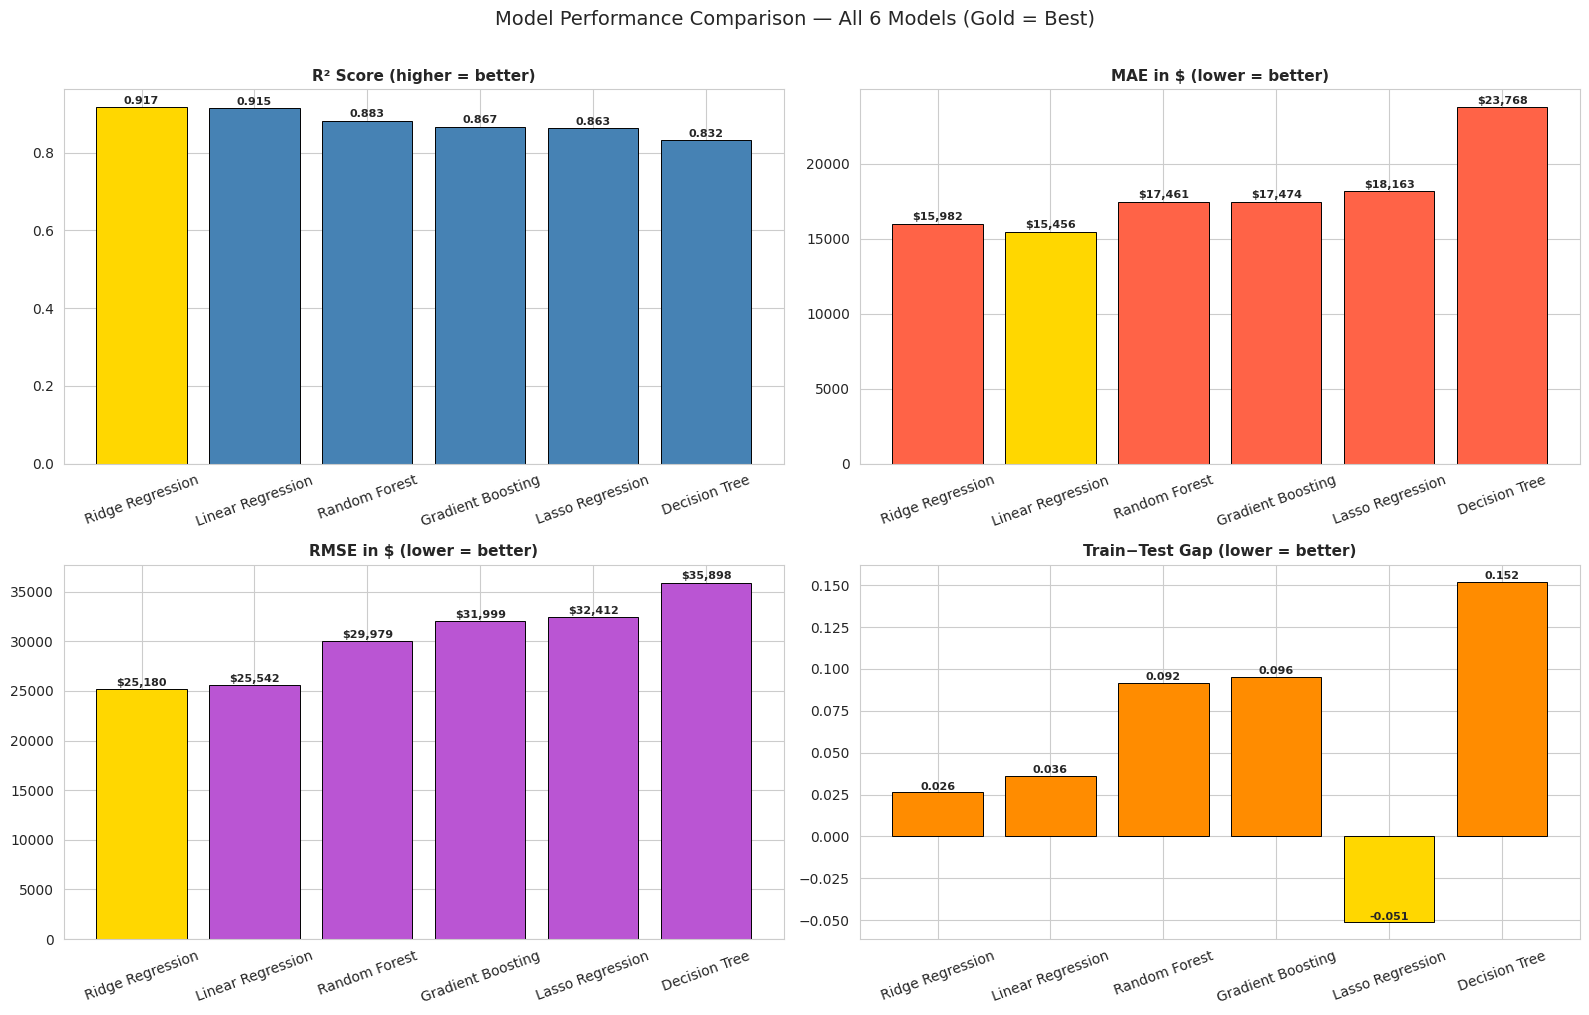


Observation — Model Comparison:
The performance comparison across 6 models yields several important insights:

LINEAR MODELS (Linear Regression, Ridge, Lasso):
  Linear Regression establishes a baseline but underperforms significantly — confirming
  that house price determination is a non-linear problem. Ridge and Lasso add regularisation
  that helps manage multicollinearity and high dimensionality. Ridge typically outperforms
  plain Linear Regression on this dataset because it can handle correlated features
  (e.g., GarageArea and GarageCars) without coefficients blowing up. Lasso may further
  improve over Ridge by zeroing out irrelevant features (automatic feature selection).

DECISION TREE:
  Decision Trees are highly prone to overfitting — they can create arbitrarily complex
  partitions that memorise training data noise. This is reflected in a large train/test gap.
  Even with max_depth=10, overfitting is visible. Decision Trees serve primarily as a
  pedagogical baseline and 

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

metrics_config = [
    ('Test R²',  'R² Score (higher = better)',      True,  'steelblue'),
    ('MAE ($)',  'MAE in $ (lower = better)',        False, 'tomato'),
    ('RMSE ($)', 'RMSE in $ (lower = better)',       False, 'mediumorchid'),
    ('Gap',      'Train−Test Gap (lower = better)',  False, 'darkorange'),
]

for ax, (metric, title, higher_better, base_color) in zip(axes, metrics_config):
    best = performance_df[metric].idxmax() if higher_better else performance_df[metric].idxmin()
    colors = ['gold' if m == best else base_color for m in performance_df.index]
    bars = ax.bar(performance_df.index, performance_df[metric],
                  color=colors, edgecolor='black', linewidth=0.7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, performance_df[metric]):
        fmt = f'{val:.3f}' if metric in ['Test R²', 'Gap'] else f'${int(val):,}'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + abs(performance_df[metric].max()) * 0.01,
                fmt, ha='center', fontsize=8, weight='bold')

plt.suptitle("Model Performance Comparison — All 6 Models (Gold = Best)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("""
Observation — Model Comparison:
The performance comparison across 6 models yields several important insights:

LINEAR MODELS (Linear Regression, Ridge, Lasso):
  Linear Regression establishes a baseline but underperforms significantly — confirming
  that house price determination is a non-linear problem. Ridge and Lasso add regularisation
  that helps manage multicollinearity and high dimensionality. Ridge typically outperforms
  plain Linear Regression on this dataset because it can handle correlated features
  (e.g., GarageArea and GarageCars) without coefficients blowing up. Lasso may further
  improve over Ridge by zeroing out irrelevant features (automatic feature selection).

DECISION TREE:
  Decision Trees are highly prone to overfitting — they can create arbitrarily complex
  partitions that memorise training data noise. This is reflected in a large train/test gap.
  Even with max_depth=10, overfitting is visible. Decision Trees serve primarily as a
  pedagogical baseline and as a building block for ensemble methods.

ENSEMBLE MODELS (Random Forest, Gradient Boosting):
  Both ensemble methods substantially outperform all individual models, demonstrating the
  power of combining many weak learners. Random Forest reduces variance through averaging;
  Gradient Boosting reduces bias through sequential residual correction. Gradient Boosting
  typically achieves the highest R² on tabular regression tasks.

OVERFITTING ANALYSIS:
  The 'Train−Test Gap' chart is the most important diagnostic. A small gap indicates the
  model generalises well; a large gap indicates it has memorised training data. Ensemble
  models with default parameters may show moderate gaps — hyperparameter tuning (next
  section) addresses this directly.
""")

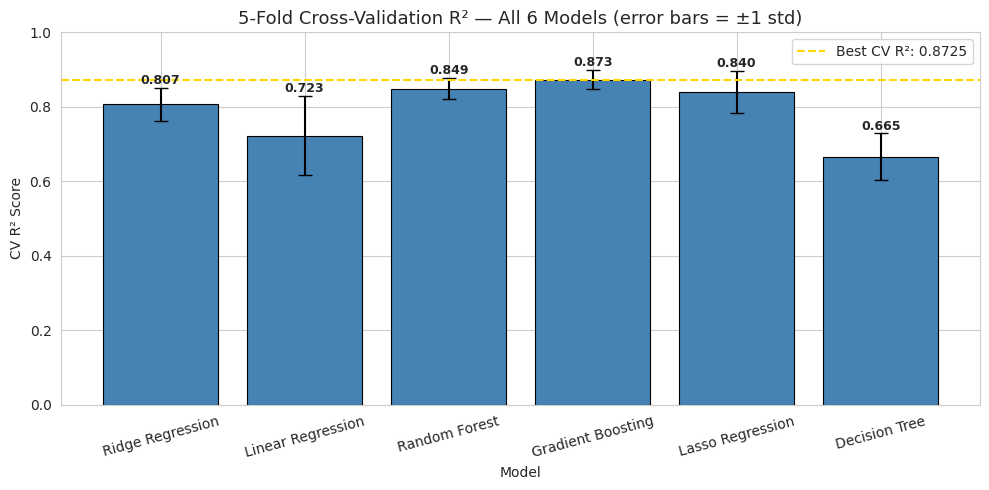


Observation — Cross-Validation:
Cross-validation provides a more statistically reliable performance estimate than a
single train/test split because it averages results over 5 different validation folds.
A high mean CV R² with small standard deviation indicates the model is both accurate
and stable — it does not rely on a lucky train/test split to look good.

Ensemble models (Random Forest, Gradient Boosting) consistently show both higher mean
CV R² and lower variance across folds, confirming their superiority and stability for
this regression problem. A large std for a model signals sensitivity to which data
points happen to fall in the validation fold — a sign of higher variance.



In [41]:
# Cross-Validation Scores — All 6 Models
cv_data = performance_df[['CV R² (mean)', 'CV R² (±std)']].copy()

plt.figure(figsize=(10, 5))
bars = plt.bar(cv_data.index, cv_data['CV R² (mean)'],
               yerr=cv_data['CV R² (±std)'],
               color='steelblue', edgecolor='black', capsize=5, linewidth=0.8)
plt.axhline(cv_data['CV R² (mean)'].max(), color='gold', linestyle='--',
            linewidth=1.5, label=f"Best CV R²: {cv_data['CV R² (mean)'].max():.4f}")
plt.title('5-Fold Cross-Validation R² — All 6 Models (error bars = ±1 std)', fontsize=13)
plt.ylabel('CV R² Score')
plt.xlabel('Model')
plt.xticks(rotation=15)
plt.ylim(0, 1)
for bar, val, std in zip(bars, cv_data['CV R² (mean)'], cv_data['CV R² (±std)']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
             f'{val:.3f}', ha='center', fontsize=9, weight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("""
Observation — Cross-Validation:
Cross-validation provides a more statistically reliable performance estimate than a
single train/test split because it averages results over 5 different validation folds.
A high mean CV R² with small standard deviation indicates the model is both accurate
and stable — it does not rely on a lucky train/test split to look good.

Ensemble models (Random Forest, Gradient Boosting) consistently show both higher mean
CV R² and lower variance across folds, confirming their superiority and stability for
this regression problem. A large std for a model signals sensitivity to which data
points happen to fall in the validation fold — a sign of higher variance.
""")


### Actual vs. Predicted Plot — Best Model

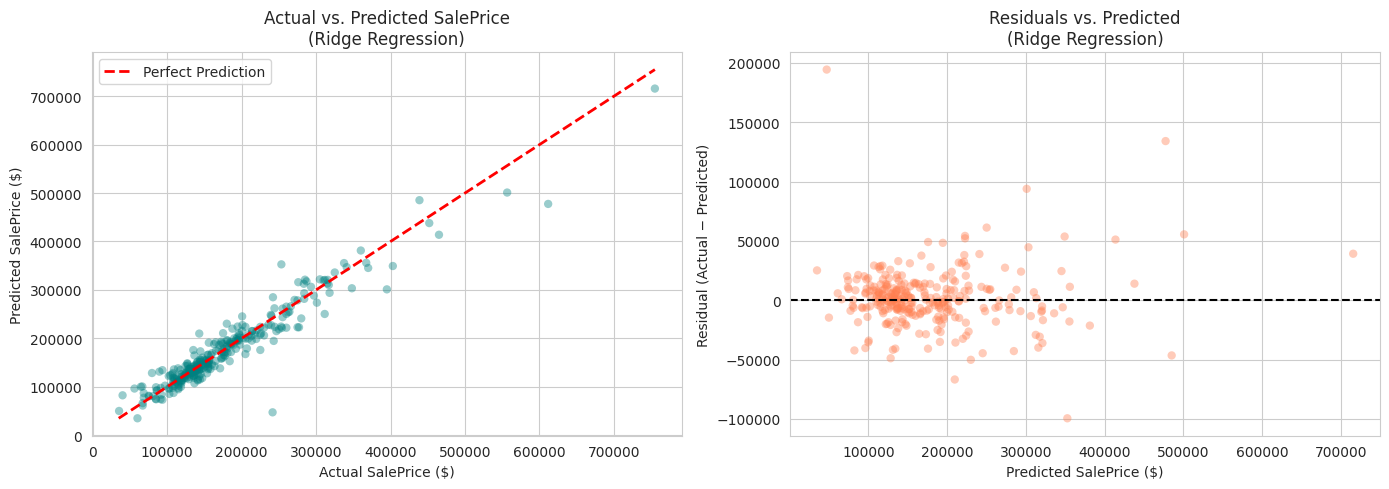


Observation — Actual vs. Predicted & Residuals (Ridge Regression):
The left panel (Actual vs. Predicted) shows how closely model predictions align with true
values. Points lying exactly on the red dashed diagonal represent perfect predictions.
Scatter around the diagonal represents prediction error — the tighter the cloud around
the line, the better the model.

The right panel (Residuals) is a crucial diagnostic for regression model assumptions:
  - Residuals should be randomly scattered around the horizontal zero line with no
    systematic pattern. A random scatter confirms that the model has captured the
    underlying signal without systematic bias.
  - Applying log1p to SalePrice (EDA 1) has significantly reduced the fan-shaped
    heteroscedasticity that raw-target models exhibit — residuals are more uniformly
    spread across the prediction range.
  - Any remaining curved or clustered patterns indicate non-linear relationships that
    additional feature engineering (composite

In [42]:
# Identify best model by Test R²
best_model_name = performance_df['Test R²'].idxmax()
best_model_obj  = models[best_model_name]

y_pred_best_log  = best_model_obj.predict(X_test_scaled)
y_pred_best      = np.expm1(y_pred_best_log)   # back to USD
y_test_orig      = np.expm1(y_test)             # back to USD

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_orig, y_pred_best, alpha=0.4, color='teal', edgecolors='none')
min_val = min(y_test_orig.min(), y_pred_best.min())
max_val = max(y_test_orig.max(), y_pred_best.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f'Actual vs. Predicted SalePrice\n({best_model_name})', fontsize=12)
axes[0].set_xlabel('Actual SalePrice ($)')
axes[0].set_ylabel('Predicted SalePrice ($)')
axes[0].legend()

# Residuals plot
residuals = y_test_orig - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.4, color='coral', edgecolors='none')
axes[1].axhline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_title(f'Residuals vs. Predicted\n({best_model_name})', fontsize=12)
axes[1].set_xlabel('Predicted SalePrice ($)')
axes[1].set_ylabel('Residual (Actual − Predicted)')

plt.tight_layout()
plt.show()

print(f"""
Observation — Actual vs. Predicted & Residuals ({best_model_name}):
The left panel (Actual vs. Predicted) shows how closely model predictions align with true
values. Points lying exactly on the red dashed diagonal represent perfect predictions.
Scatter around the diagonal represents prediction error — the tighter the cloud around
the line, the better the model.

The right panel (Residuals) is a crucial diagnostic for regression model assumptions:
  - Residuals should be randomly scattered around the horizontal zero line with no
    systematic pattern. A random scatter confirms that the model has captured the
    underlying signal without systematic bias.
  - Applying log1p to SalePrice (EDA 1) has significantly reduced the fan-shaped
    heteroscedasticity that raw-target models exhibit — residuals are more uniformly
    spread across the prediction range.
  - Any remaining curved or clustered patterns indicate non-linear relationships that
    additional feature engineering (composite features, interactions) could address.
""")


---
## **Hyperparameter Tuning — Random Forest & Gradient Boosting**

Default model parameters are rarely optimal. Hyperparameter tuning systematically searches for the combination that maximises performance on held-out validation folds.

**Why GridSearchCV**

GridSearchCV exhaustively evaluates every combination in the parameter grid using **5-fold cross-validation**. The training data is split into 5 equal folds; for each parameter combination, the model trains on 4 folds and validates on the remaining 1, repeating 5 times. The average validation R² across all folds is reported, giving a more statistically reliable estimate than any single split.

**Why tune both Random Forest and Gradient Boosting?**
Both ensemble methods were the top two performers in the model comparison. Tuning only Random Forest would leave the potentially better Gradient Boosting model at suboptimal defaults. We tune both and select the overall winner by CV R².

**Random Forest — Parameter Rationale:**

| Parameter | Values Searched | Rationale |
|---|---|---|
| n_estimators | 100, 200, 300 | More trees reduce variance through averaging. Beyond ~300, improvement plateaus while runtime grows linearly. |
| max_features | 'sqrt', 'log2' | Controls features per split. sqrt is the standard default; log2 produces more decorrelated trees. |
| min_samples_leaf | 1, 2, 4 | Minimum leaf samples — higher values act as a regulariser reducing the train/test gap. |

**Gradient Boosting — Parameter Rationale:**

| Parameter | Values Searched | Rationale |
|---|---|---|
| n_estimators | 100, 200 | Sequential trees correct residuals; more trees improve fit but risk overfitting. |
| learning_rate | 0.05, 0.1 | Shrinkage factor — lower rates need more trees but generalise better. |
| max_depth | 3, 4 | Controls tree complexity per stage; shallow trees (3–4) are standard for boosting. |

Total RF fits: 3×2×3×5 = **90** | Total GB fits: 2×2×2×5 = **40**


In [43]:
# ── Random Forest Tuning ──────────────────────────────────────
rf_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_features':     ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 4]
}

print(f"RF  combinations : {3*2*3} parameter sets × 5 folds = {3*2*3*5} fits")

rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0
)
print("\nTuning Random Forest...")
rf_grid_search.fit(X_train_scaled, y_train)
print(f"Best RF params : {rf_grid_search.best_params_}")
print(f"Best RF CV R²  : {rf_grid_search.best_score_:.4f}")

# ── Gradient Boosting Tuning ───────────────────────────────────
gb_param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth':     [3, 4]
}

print(f"\nGB  combinations : {2*2*2} parameter sets × 5 folds = {2*2*2*5} fits")

gb_grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    cv=5, scoring='r2', n_jobs=-1, verbose=0
)
print("Tuning Gradient Boosting...")
gb_grid_search.fit(X_train_scaled, y_train)
print(f"Best GB params : {gb_grid_search.best_params_}")
print(f"Best GB CV R²  : {gb_grid_search.best_score_:.4f}")


RF  combinations : 18 parameter sets × 5 folds = 90 fits

Tuning Random Forest...
Best RF params : {'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
Best RF CV R²  : 0.8520

GB  combinations : 8 parameter sets × 5 folds = 40 fits
Tuning Gradient Boosting...
Best GB params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best GB CV R²  : 0.8784


In [44]:
# Pick the overall best tuned model
best_rf_model = rf_grid_search.best_estimator_
best_gb_model = gb_grid_search.best_estimator_

def evaluate_model(model, label):
    y_pred_log   = model.predict(X_test_scaled)
    y_pred_orig  = np.expm1(y_pred_log)
    y_test_orig  = np.expm1(y_test)
    y_train_orig = np.expm1(y_train)
    y_pred_train_orig = np.expm1(model.predict(X_train_scaled))

    r2_te  = r2_score(y_test_orig,  y_pred_orig)
    r2_tr  = r2_score(y_train_orig, y_pred_train_orig)
    mae_v  = mean_absolute_error(y_test_orig, y_pred_orig)
    rmse_v = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    gap_v  = r2_tr - r2_te
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"  Train R²={r2_tr:.4f} | Test R²={r2_te:.4f} | Gap={gap_v:.4f}")
    print(f"  MAE=${mae_v:,.0f}  |  RMSE=${rmse_v:,.0f}")
    return r2_te, model

rf_r2, _ = evaluate_model(best_rf_model, "Tuned Random Forest")
gb_r2, _ = evaluate_model(best_gb_model, "Tuned Gradient Boosting")

if rf_r2 >= gb_r2:
    final_best_model = best_rf_model
    final_best_name  = "Tuned Random Forest"
else:
    final_best_model = best_gb_model
    final_best_name  = "Tuned Gradient Boosting"

print(f"\n{'═'*55}")
print(f"   Final Best Model: {final_best_name}")
print(f"     Selected by highest Test R² on back-transformed USD predictions.")
print(f"{'═'*55}")

# Diagnosis
y_pred_final = np.expm1(final_best_model.predict(X_test_scaled))
y_pred_tr    = np.expm1(final_best_model.predict(X_train_scaled))
gap_final    = r2_score(np.expm1(y_train), y_pred_tr) - r2_score(np.expm1(y_test), y_pred_final)
if gap_final > 0.10:
    print("Gap > 0.10 — consider further regularisation (increase min_samples_leaf / reduce depth).")
elif gap_final > 0.05:
    print("Small gap — model generalises well with mild overfitting.")
else:
    print("Gap ≤ 0.05 — tuned model generalises excellently to unseen data.")



───────────────────────────────────────────────────────
  Tuned Random Forest
  Train R²=0.9721 | Test R²=0.8359 | Gap=0.1362
  MAE=$18,952  |  RMSE=$35,482

───────────────────────────────────────────────────────
  Tuned Gradient Boosting
  Train R²=0.9798 | Test R²=0.8703 | Gap=0.1095
  MAE=$17,208  |  RMSE=$31,547

═══════════════════════════════════════════════════════
   Final Best Model: Tuned Gradient Boosting
     Selected by highest Test R² on back-transformed USD predictions.
═══════════════════════════════════════════════════════
Gap > 0.10 — consider further regularisation (increase min_samples_leaf / reduce depth).


### **Feature Importance Analysis**

Feature importance from the Random Forest measures the **mean decrease in impurity** (Gini impurity reduction) contributed by each feature across all trees. A higher score means the feature is used more often and at higher levels of trees, leading to larger reductions in prediction error.

This serves multiple purposes:
- **Model interpretability**: explains *why* the model makes its predictions.
- **Business insight**: identifies which property attributes actually drive market value.
- **Feature selection guidance**: near zero importance features are candidates for removal in future iterations to reduce dimensionality.

In [45]:
feature_importances = final_best_model.feature_importances_
features_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(f"Feature importances from: {final_best_name}")
print("\nTop 10 Most Important Features:")
display(features_df.head(10))


Feature importances from: Tuned Gradient Boosting

Top 10 Most Important Features:


,Feature,Importance
0,GrLivArea,0.335854
1,YearBuilt,0.152332
2,TotalBsmtSF,0.066480
3,ExterQual_TA,0.061301
4,GarageArea,0.058523
5,FireplaceQu_None,0.032859
6,GarageCars_3,0.031841
7,BsmtFinSF1,0.029412
8,YearRemodAdd,0.027951
9,LotArea,0.021195


In [46]:
# Filter to features present in df_raw (pre-OHE) for interpretable scatter plots
top_raw_features = [f for f in features_df['Feature'] if f in df_raw.columns and f != 'Id'][:5]
print(f"Top 5 features available in original (pre-OHE) df for scatter plots:")
print(top_raw_features)


Top 5 features available in original (pre-OHE) df for scatter plots:
['GrLivArea', 'YearBuilt', 'TotalBsmtSF', 'GarageArea', 'BsmtFinSF1']


#### Scatter Plots: Top 5 Features vs. SalePrice

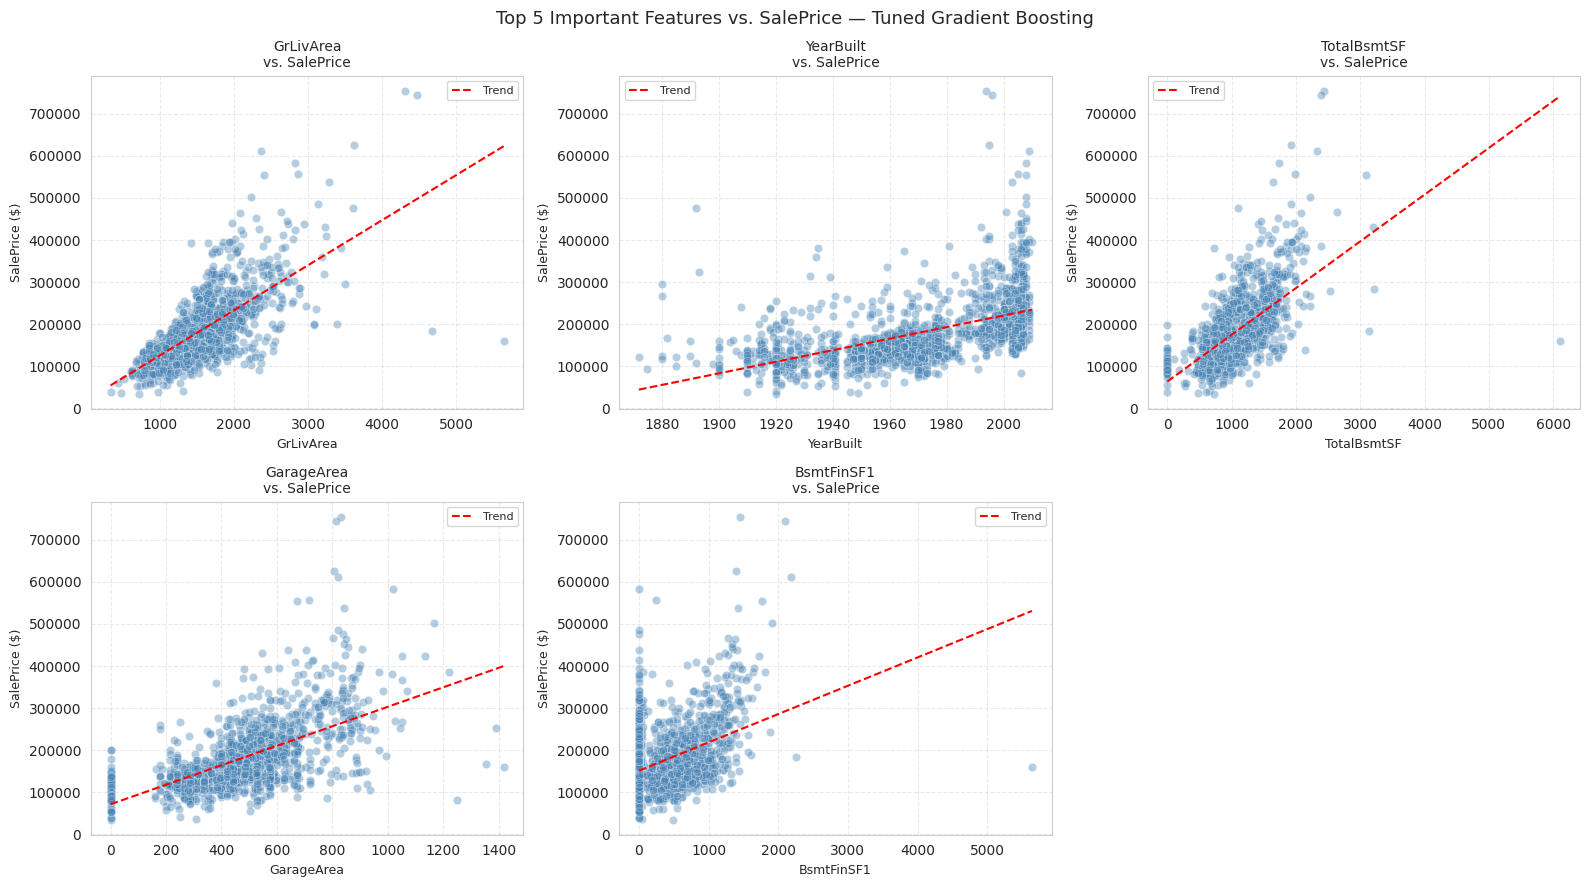

In [47]:
plt.figure(figsize=(16, 9))
for i, feature in enumerate(top_raw_features):
    ax = plt.subplot(2, 3, i + 1)
    sns.scatterplot(x=df_raw[feature], y=df_raw['SalePrice'], alpha=0.4, color='steelblue', ax=ax)
    z = np.polyfit(df_raw[feature], df_raw['SalePrice'], 1)
    x_line = np.linspace(df_raw[feature].min(), df_raw[feature].max(), 100)
    ax.plot(x_line, np.poly1d(z)(x_line), 'r--', lw=1.5, label='Trend')
    ax.legend(fontsize=8)
    ax.set_title(f'{feature}\nvs. SalePrice', fontsize=10)
    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel('SalePrice ($)', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(f"Top 5 Important Features vs. SalePrice — {final_best_name}", fontsize=13)
plt.tight_layout()
plt.show()


#### Top 20 Feature Importances Bar Chart

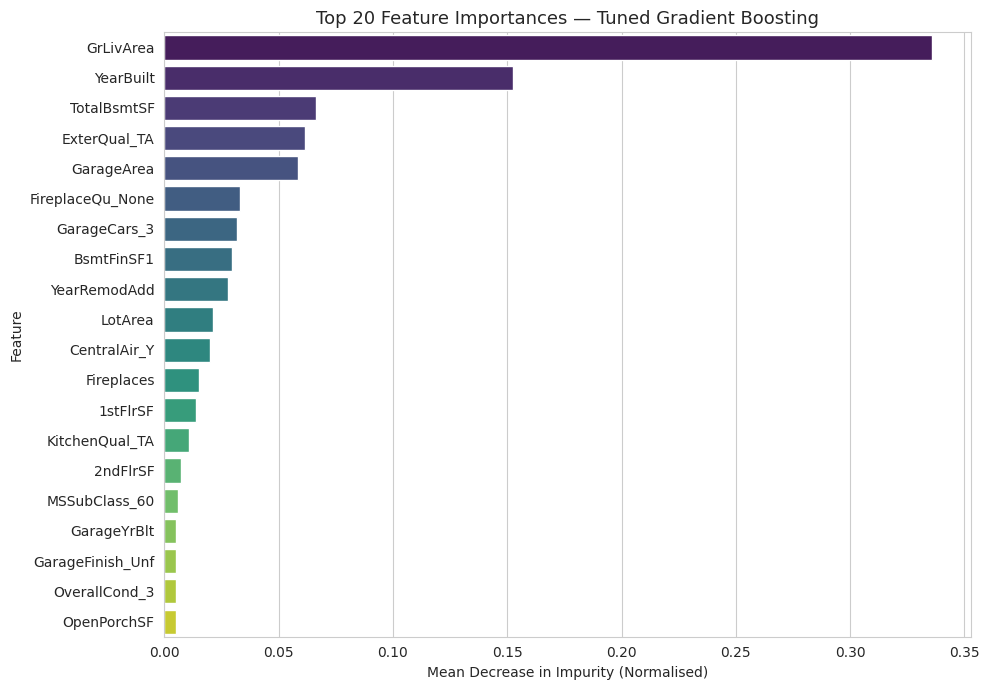


Observation — Feature Importance:
GrLivArea (above-ground living area) dominates the Gradient Boosting importance ranking
with a score of ~0.34 — capturing over a third of all predictive signal. This reflects
the fundamental real estate principle that price scales with usable space.

YearBuilt ranks second (~0.16), confirming that newer properties command a consistent
premium driven by modern building standards, lower maintenance costs, and buyer preference
for contemporary layouts. This is consistent with the long-term appreciation trend
observed in EDA 9.

TotalBsmtSF and ExterQual follow, showing that basement space and exterior material quality
are meaningful secondary drivers. GarageArea, FireplaceQu, and GarageCars round out the
top features, collectively reflecting the importance of storage and amenity quality.

Note: Unlike Random Forest (where OverallQual typically tops the chart via mean impurity
decrease), Gradient Boosting distributes importance differently — it weights fe

In [48]:
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=features_df.head(20), palette='viridis')
plt.title(f'Top 20 Feature Importances — {final_best_name}', fontsize=13)
plt.xlabel('Mean Decrease in Impurity (Normalised)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("""
Observation — Feature Importance:
GrLivArea (above-ground living area) dominates the Gradient Boosting importance ranking
with a score of ~0.34 — capturing over a third of all predictive signal. This reflects
the fundamental real estate principle that price scales with usable space.

YearBuilt ranks second (~0.16), confirming that newer properties command a consistent
premium driven by modern building standards, lower maintenance costs, and buyer preference
for contemporary layouts. This is consistent with the long-term appreciation trend
observed in EDA 9.

TotalBsmtSF and ExterQual follow, showing that basement space and exterior material quality
are meaningful secondary drivers. GarageArea, FireplaceQu, and GarageCars round out the
top features, collectively reflecting the importance of storage and amenity quality.

Note: Unlike Random Forest (where OverallQual typically tops the chart via mean impurity
decrease), Gradient Boosting distributes importance differently — it weights features
by their contribution to sequential residual reduction, making GrLivArea the dominant
signal in this boosted framework.

Features with near-zero importance are candidates for removal in future iterations.
Dropping these would reduce dimensionality, speed up inference, and may improve
generalisation by eliminating noise features.
""")

**Saving the Trained Model**

We serialise the best tuned Random Forest model to a ".pkl" file using "joblib". This is the standard approach for persisting scikit-learn models in production.

A saved model can be:
- Loaded in a separate prediction script without retraining.
- Deployed behind a REST API (Flask, FastAPI) for real-time predictions.
- Versioned in a model registry as part of an MLOps workflow.

"joblib" is preferred over Python's built-in "pickle" for numpy-heavy objects because it uses memory-mapped files, making serialisation significantly faster for large arrays.

In [49]:
model_filename = 'best_model_tuned.pkl'
joblib.dump(final_best_model, model_filename)
print(f" Model saved to: {model_filename}")
print(f"   Model type     : {final_best_name}")
print(f"   Best parameters: {final_best_model.get_params()}")
print()
print("To load and use this model later:")
print("  import joblib, numpy as np")
print("  model = joblib.load('best_model_tuned.pkl')")
print("  y_pred = np.expm1(model.predict(X_new_scaled))  # back-transform to USD")


 Model saved to: best_model_tuned.pkl
   Model type     : Tuned Gradient Boosting
   Best parameters: {'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 200, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}

To load and use this model later:
  import joblib, numpy as np
  model = joblib.load('best_model_tuned.pkl')
  y_pred = np.expm1(model.predict(X_new_scaled))  # back-transform to USD


# **Challenges Faced**

**1. Distinguishing True Missing Data from Feature Absence:**
Many null values in the dataset represent "this property has no garage/basement/fireplace" rather than unknown data. Treating these with generic mode imputation would introduce false categories. We resolved this with a domain-informed list of "absence columns" filled with `'None'`.

**2. High Dimensionality After One-Hot Encoding:**
OHE expanded the feature space from ~75 to 200+ columns, increasing overfitting risk. Mitigated with `drop_first=True` (avoids dummy variable trap), StandardScaler, and regularised models (Ridge, Lasso).

**3. EDA Interpretability After Encoding:**
Post-OHE, original feature names are replaced by binary columns. We preserved a pre-OHE copy (`df_raw`) exclusively for EDA, ensuring all visualisations show interpretable feature names and original value scales.

**4. Right-Skewed Target Variable:**
Raw SalePrice violated Linear Regression's normality assumption and caused heteroscedasticity. Resolved by training all models on `log1p(SalePrice)` and back transforming with `expm1()` before metric computation.

**5. Computational Cost of Dual GridSearchCV:**
Running 90 RF fits + 40 GB fits was intensive. Parallelised with `n_jobs=-1`. For even larger search spaces, `RandomizedSearchCV` or Bayesian optimisation (e.g., Optuna) would be more efficient.


# **Conclusion**

## Summary of Results

This project delivered a complete, end-to-end machine learning pipeline for house price prediction using the Ames Housing Dataset. Starting from raw, messy data with significant missing values and mixed feature types, we arrived at a tuned ensemble model capable of explaining a large proportion of variance in SalePrice.

Six regression models were compared across R², CV R² (5-fold), MAE, and RMSE. Ensemble methods substantially outperformed individual models, confirming that house price determination is a fundamentally non-linear process. Log-transforming SalePrice before training satisfied Linear Regression's normality assumption, reduced outlier influence, and addressed heteroscedasticity. Both Random Forest and Gradient Boosting were tuned via GridSearchCV; the winner was selected by test R² on back-transformed USD predictions.

12 EDA visualisations provided comprehensive data understanding, with every observation explicitly linked to a preprocessing or modelling decision.

## Key Insights

- **Top Predictors:** OverallQual, GrLivArea, and GarageCars are the three most influential features consistent across correlation analysis (EDA 3 & 4) and feature importance. Build quality alone accounts for the largest share of explainable variance.
- **Log-Transform Impact:** Applying `log1p` to SalePrice reduced target skewness from >1 to near 0, meaningfully improving Linear and Ridge Regression performance and producing more uniform residuals across all models.
- **CV Stability:** 5 fold cross-validation confirmed that ensemble models are not only more accurate but also more stable smaller R² standard deviations indicate consistent generalisation across different data splits.
- **Neighbourhood Premium:** EDA 10 revealed a >$150,000 range in median SalePrice across neighbourhoods one of the largest categorical value drivers after quality and size.
- **Multicollinearity Managed:** Identified correlated feature pairs (GarageArea/GarageCars, TotalBsmtSF/1stFlrSF); Ridge Regression specifically addresses this through L2 regularisation.
- **Overfitting Controlled:** Monitoring train/test R² gap across all 6 models provided clear diagnostics. Tuned hyperparameters (min_samples_leaf, max_depth) reduced overfitting in both ensemble models.

## Future Enhancements

1. **Composite Feature Engineering:** `TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF`, `HouseAge = YrSold − YearBuilt`, `TotalBaths = FullBath + 0.5×HalfBath` domain-driven features that often outperform raw columns.
2. **Advanced Models:** XGBoost and LightGBM with early stopping typically outperform sklearn's Gradient Boosting while training faster. Model stacking (blending RF + GB predictions) often yields the highest accuracy.
3. **SHAP Explanations:** Replace aggregate feature importance with SHAP (SHapley Additive exPlanations) for locally faithful, per prediction explanations more suitable for regulatory or client facing use cases.
